In [33]:
"""
auto_align.py
=============
Auto-registration of a MALDI imzML dataset against a whole-slide H&E image.

Key design decisions
--------------------
1.  Registration is performed at MALDI native pixel size (default 10 um/px)
    so the H&E thumbnail is tiny and peak RAM stays manageable.

2.  Matching uses normalised grayscale cross-correlation (TM_CCOEFF_NORMED)
    on the TIC image vs inverted H&E intensity.

3.  A two-pass rotation search (coarse 0-360, then fine) finds the correct
    slide orientation without assuming any starting angle.

4.  Optional QuPath GeoJSON annotations can be passed via geojson_path.
    They are transformed using the same cv2.warpAffine matrix used to build
    the H&E canvas, guaranteeing pixel-perfect consistency between the image
    and annotation coordinate systems.

Annotation transform approach
------------------------------
The H&E canvas is built with cv2.warpAffine using an analytically derived
affine matrix (rotate around image centre, remove bounding-box shift, add
canvas placement offset).  The same matrix is applied to annotation vertices,
so the two are guaranteed to be consistent -- no PIL internals, no
reconstruction, no least-squares fitting required.

    Image:       cv2.warpAffine(img, M_stored[:2,:], (canvas_w, canvas_h))
    Annotations: M_full = M_up @ M_stored @ M_scale
                 applied per-vertex to GeoJSON coordinates
"""

from __future__ import annotations

import os
import gc
import json
from functools import partial
from pathlib import Path
from typing import Optional, Union

import numpy as np
import pandas as pd
import anndata as ad
import geopandas as gpd
import cv2 as cv
from PIL import Image
from shapely.geometry import box, shape
from shapely import transform as shapely_transform

from spatialdata import SpatialData
from spatialdata.models import Image2DModel, PointsModel, ShapesModel, TableModel
from spatialdata.transformations import Identity

import numpy as np
from pyimzml.ImzMLParser import ImzMLParser, getionimage
from joblib import Parallel, delayed
from functools import partial
import anndata as ad
import pandas as pd
import geopandas as gpd
from shapely.geometry import box
import numpy as np
from anndata import AnnData
from spatialdata import SpatialData
from spatialdata.models import PointsModel, Image2DModel, TableModel, ShapesModel
from spatialdata.transformations import Identity
import pkg_resources
import os



def parmap(f, X, nprocs=None):
    """
    Parallel map using joblib (more robust for Jupyter).
    
    Parameters
    ----------
    f : callable
        Function to apply to each element
    X : iterable
        Input data
    nprocs : int, optional
        Number of processes (default: -1, all CPUs)
    
    Returns
    -------
    list
        Results in same order as input
    """
    if nprocs is None:
        nprocs = -1  # Use all CPUs
    
    return Parallel(n_jobs=nprocs, backend='loky')(
        delayed(f)(x) for x in X
    )


def getimage(peak, path, tol = 0.1): 
    p =  ImzMLParser(path) #individual file pointers otherwise parsing is corrupted
    return getionimage(p, peak, tol=tol, reduce_func=max)
    

def rd_peaks(fn):
    data = []
    with open(fn) as f:
        f.readline() #header
        for line in f:
            ss = line.split()
            if ss[0].strip('"') == 'M': continue
            data.append(float(ss[1]))
    return data


def rd_peaks_from_package():

    # Try to get the file from the package
    peaks_path = pkg_resources.resource_filename('goatpy', 'data/PEAKS.csv')
    
    if not os.path.exists(peaks_path):
        raise FileNotFoundError(f"PEAKS.csv not found at {peaks_path}")
    
    with open(peaks_path, 'r') as f:
        data = []
        f.readline()  # skip header
        for line in f:
            ss = line.split()
            if ss[0].strip('"') == 'M': 
                continue
            data.append(float(ss[1]))
    return data


def glyco_spatialdata(imzml_path, peaks_path = None, tol = 0.1, pixel_size = 20):

    # Load Peaks
    if peaks_path is None:
        peaks = rd_peaks_from_package()
    else:
        peaks = rd_peaks(peaks_path)

    # Load ImzML data
    getimg = partial(getimage, path=imzml_path, tol = tol)

    spectra_all = np.stack(
        parmap(getimg, peaks, 10),
        axis=-1
    )

    # Load Spatial Info
    p = ImzMLParser(imzml_path)
    coords = np.array(p.coordinates)[:, :2]  # (x, y)
    coords = coords - 1  # convert from 1-based to 0-based indexing
    

    # Create AnnData Object
    spectra_flat = np.array([spectra_all[y-1, x-1, :] for x, y in coords])
    anndata = ad.AnnData(spectra_flat, dtype=np.float32)
    anndata.var_names = np.array(["%.1f" % p for p in peaks])
    anndata.obs_names = np.array(list(map(str, range(len(coords)))))
    anndata.obs["full_x"] = coords[:, 0]
    anndata.obs["full_y"] = coords[:, 1]

    anndata.obs["x"] = anndata.obs["full_x"] - anndata.obs["full_x"].min() 
    anndata.obs["y"] = anndata.obs["full_y"] - anndata.obs["full_y"].min()
    

    anndata.obsm["spatial"] = np.column_stack([anndata.obs["x"], anndata.obs["y"]])


    # Calculate Total Ion Count (TIC)
    anndata.obs["MPI"] = np.ravel(anndata.X.sum(axis=1))

    
    # Create SpatialData Object
    coords = pd.DataFrame({
        "x": [c for c in anndata.obs["x"]],
        "y": [c for c in anndata.obs["y"]],
    })

    coords["instance_id"] = coords.index.astype(str)      # unique ID for each pixel
    coords["region"] = "pixels"                  # must exist for TableModel

    df = pd.concat(
        [
            coords.reset_index(drop=True),
            pd.DataFrame(anndata.X, columns=("mz-" + anndata.var.index))
        ],
        axis=1
    )

    
    points = PointsModel.parse(df)

    gdf = centroids_to_pixel_squares(df, x_col="x", y_col="y", pixel_size=1.0)  
    
    shapes = ShapesModel.parse(
                gdf[["instance_id", "geometry"]],
                transformations={"global": Identity()},
                )


    sdata = SpatialData(points={"centroids": points},
                        shapes={"pixels": shapes})


    adata = AnnData(
        X=anndata.X,
        obs=coords,  # contains x, y, point_id, region
        var=pd.DataFrame(index=("mz-" + anndata.var.index))
    )

    adata.obs = pd.concat(
        [
            adata.obs.reset_index(drop=True),
            anndata.obs.drop(columns=["x", "y"]).iloc[:adata.n_obs].reset_index(drop=True)
        ],
        axis=1
    )

    coords = np.array(adata.obs[["x", "y"]])

    adata.obsm["spatial"] = coords
    adata.obs["instance_id"] = sdata["pixels"].index
    adata.obs["region"] = "pixels"
    adata.obs["region"].astype("category")



    table = TableModel.parse(
        adata,
        region="pixels",      # name of your PointsModel
        region_key="region",        # must exist in adata.obs
        instance_key="instance_id"     # unique per row
    )

    # --- 7. Add to SpatialData ---
    sdata.tables["maldi_adata"] = table

    return sdata


def centroids_to_pixel_squares(df, x_col="x", y_col="y", pixel_size=1.0):
    
    half = pixel_size / 2
    
    geometries = [
        box(x - half, y - half, x + half, y + half)
        for x, y in zip(df[x_col], df[y_col])
    ]
    
    gdf = gpd.GeoDataFrame(
        df.copy(),
        geometry=geometries,
    )
    
    return gdf

from pyimzml.ImzMLParser import ImzMLParser


# ---------------------------------------------------------------------------
# Logging
# ---------------------------------------------------------------------------

def _log(msg: str) -> None:
    try:
        import psutil
        rss = psutil.Process(os.getpid()).memory_info().rss / 1e9
        print(f"[{rss:.2f}GB] {msg}")
    except ImportError:
        print(msg)


# ---------------------------------------------------------------------------
# H&E loading
# ---------------------------------------------------------------------------

def _read_native_mpp(he_path: str) -> Optional[float]:
    """Read native microns-per-pixel from file metadata without loading pixels."""
    try:
        import openslide
        slide = openslide.OpenSlide(he_path)
        mpp_x = slide.properties.get(openslide.PROPERTY_NAME_MPP_X)
        mpp_y = slide.properties.get(openslide.PROPERTY_NAME_MPP_Y)
        slide.close()
        if mpp_x and mpp_y:
            return (float(mpp_x) + float(mpp_y)) / 2.0
    except Exception:
        pass
    return None


def _load_he_at_resolution(he_path: str,
                            target_mpp: float,
                            native_mpp: float) -> tuple[Image.Image, float]:
    """
    Load H&E at (or just finer than) target_mpp using openslide pyramid
    selection, then resize to exactly target_mpp.
    """
    ext = os.path.splitext(he_path)[1].lower()
    wsi_exts = {'.svs', '.ndpi', '.scn', '.czi', '.mrxs'}

    try:
        import openslide
        slide = openslide.OpenSlide(he_path)

        best_level = 0
        best_mpp   = native_mpp
        for lvl in range(slide.level_count):
            lvl_mpp = native_mpp * slide.level_downsamples[lvl]
            if lvl_mpp <= target_mpp * 1.05:
                best_level = lvl
                best_mpp   = lvl_mpp

        dims   = slide.level_dimensions[best_level]
        region = slide.read_region((0, 0), best_level, dims)
        img    = region.convert('RGB')
        slide.close()
        _log(f"  openslide level {best_level}: {dims[0]}x{dims[1]}  "
             f"{best_mpp:.3f} um/px  ({img.width*img.height*3/1e6:.0f} MB)")

        if abs(best_mpp - target_mpp) / target_mpp > 0.02:
            scale = best_mpp / target_mpp
            nw    = max(1, round(img.width  * scale))
            nh    = max(1, round(img.height * scale))
            img   = img.resize((nw, nh), Image.Resampling.LANCZOS)
            best_mpp = target_mpp
            _log(f"  Resized to {nw}x{nh}  {target_mpp:.3f} um/px")

        return img, best_mpp

    except Exception as e:
        if ext in wsi_exts:
            raise RuntimeError(
                f"\nFailed to open '{he_path}' with openslide: {e}\n\n"
                "SVS/NDPI files require openslide:\n"
                "  conda install -c conda-forge openslide openslide-python\n"
            ) from e

    img = Image.open(he_path).convert('RGB')
    _log(f"  PIL: {img.width}x{img.height}")
    scale = native_mpp / target_mpp
    nw    = max(1, round(img.width  * scale))
    nh    = max(1, round(img.height * scale))
    img   = img.resize((nw, nh), Image.Resampling.LANCZOS)
    _log(f"  Resized to {nw}x{nh}  {target_mpp:.3f} um/px  ({nw*nh*3/1e6:.0f} MB)")
    return img, target_mpp


# ---------------------------------------------------------------------------
# MALDI loading
# ---------------------------------------------------------------------------

def _load_spectra(imzml_path: str,
                  peaks: list[float],
                  chunk_size: int = 10,
                  crop_r: int = 0,
                  crop_c: int = 0) -> np.ndarray:
    from pyimzml.ImzMLParser import getionimage
    p0    = ImzMLParser(imzml_path)
    probe = getionimage(p0, peaks[0], tol=0.1, reduce_func=max)
    h     = probe.shape[0] - crop_r
    w     = probe.shape[1] - crop_c
    del probe

    out = np.zeros((h, w, len(peaks)), dtype=np.float32)
    for start in range(0, len(peaks), chunk_size):
        batch = peaks[start: start + chunk_size]
        imgs  = parmap(partial(getimage, path=imzml_path), batch,
                       nprocs=min(len(batch), 4))
        for j, img in enumerate(imgs):
            out[:, :, start + j] = img[crop_r:, crop_c:]
        del imgs
        _log(f"  Peaks {start+1}-{min(start+len(batch), len(peaks))} / {len(peaks)}")
    return out


def _read_maldi_pixel_size(imzml_path: str) -> Optional[float]:
    try:
        p = ImzMLParser(imzml_path)
        for key in ['pixel size (x)', 'pixel size x', 'pixel size']:
            val = p.imzmldict.get(key)
            if val is not None:
                return float(val)
    except Exception:
        pass
    return None


def _crop_offsets(spectra_sum: np.ndarray, cutoff: float = 0.5) -> tuple[int, int]:
    try:
        crop_c = int(max(np.where(np.sum(spectra_sum, axis=0) < cutoff)[0]))
        crop_r = int(max(np.where(np.sum(spectra_sum, axis=1) < cutoff)[0]))
        return crop_r, crop_c
    except (ValueError, IndexError):
        return 0, 0


# ---------------------------------------------------------------------------
# Image preparation
# ---------------------------------------------------------------------------

def _maldi_to_grayscale(tic: np.ndarray) -> np.ndarray:
    blurred = cv.GaussianBlur(tic, (3, 3), 0)
    mn, mx  = blurred.min(), blurred.max()
    norm    = (blurred - mn) / (mx - mn) if mx > mn else blurred * 0.0
    _log(f"  MALDI grayscale: {norm.shape}  mean={norm.mean():.3f}")
    return norm.astype(np.float32)


def _he_to_grayscale(he_img: Image.Image) -> np.ndarray:
    gray = np.array(he_img.convert('L'), dtype=np.float32)
    inv  = 255.0 - gray
    mn, mx = inv.min(), inv.max()
    norm   = (inv - mn) / (mx - mn) if mx > mn else inv * 0.0
    _log(f"  H&E grayscale: {norm.shape}  mean={norm.mean():.3f}")
    return norm.astype(np.float32)


# ---------------------------------------------------------------------------
# Registration
# ---------------------------------------------------------------------------

def _match_at_rotation(he_gray: np.ndarray,
                        maldi_gray: np.ndarray,
                        rotation: float,
                        canvas_shape: tuple[int, int]) -> tuple[float, tuple[int, int]]:
    he_pil  = Image.fromarray((he_gray * 255).astype(np.uint8))
    rot_pil = he_pil.rotate(rotation, expand=True, resample=Image.Resampling.BILINEAR)
    rot_arr = np.array(rot_pil, dtype=np.float32) / 255.0

    rh, rw = rot_arr.shape
    canvas = np.zeros(canvas_shape, dtype=np.float32)
    pr     = max(0, (canvas_shape[0] - rh) // 2)
    pc     = max(0, (canvas_shape[1] - rw) // 2)
    use_h  = min(rh, canvas_shape[0] - pr)
    use_w  = min(rw, canvas_shape[1] - pc)
    canvas[pr: pr + use_h, pc: pc + use_w] = rot_arr[:use_h, :use_w]

    if canvas.shape[0] < maldi_gray.shape[0] or canvas.shape[1] < maldi_gray.shape[1]:
        raise ValueError(
            f"H&E canvas ({canvas.shape[1]}x{canvas.shape[0]} px) is smaller than "
            f"MALDI template ({maldi_gray.shape[1]}x{maldi_gray.shape[0]} px).\n"
            f"Try passing maldi_pixel_um=10 or maldi_pixel_um=20 explicitly."
        )

    result           = cv.matchTemplate(canvas, maldi_gray, cv.TM_CCOEFF_NORMED)
    _, score, _, loc = cv.minMaxLoc(result)
    return float(score), (int(loc[1]), int(loc[0]))


def _register(he_gray: np.ndarray,
              maldi_gray: np.ndarray,
              coarse_step: int = 15,
              fine_range: float = 5.0,
              fine_step: float = 1.0,
              buffer_px: int = 150) -> tuple[float, tuple[int, int]]:
    canvas_h     = he_gray.shape[0] + buffer_px
    canvas_w     = he_gray.shape[1] + buffer_px
    canvas_shape = (canvas_h, canvas_w)

    coarse_rots = list(range(0, 360, coarse_step))
    _log(f"  Coarse: {len(coarse_rots)} rotations (0-360 step {coarse_step}) ...")

    best_score = -np.inf
    best_rot   = 0.0
    best_idx   = (0, 0)

    for rot in coarse_rots:
        score, idx = _match_at_rotation(he_gray, maldi_gray, rot, canvas_shape)
        _log(f"    {rot:5.1f}  score={score:.4f}")
        if score > best_score:
            best_score, best_rot, best_idx = score, float(rot), idx

    _log(f"  Best coarse: {best_rot}  score={best_score:.4f}")

    fine_rots = sorted({
        round(best_rot + d, 1)
        for d in np.arange(-fine_range, fine_range + fine_step, fine_step)
        if abs(d) > 1e-6
    })
    _log(f"  Fine: {len(fine_rots)} rotations (+-{fine_range} step {fine_step}) ...")

    for rot in fine_rots:
        score, idx = _match_at_rotation(he_gray, maldi_gray, rot, canvas_shape)
        _log(f"    {rot:5.1f}  score={score:.4f}")
        if score > best_score:
            best_score, best_rot, best_idx = score, rot, idx

    _log(f"  Final: {best_rot}  score={best_score:.4f}  offset={best_idx}")
    return best_rot, best_idx


# ---------------------------------------------------------------------------
# Build H&E canvas with cv2.warpAffine + derive affine matrix
# ---------------------------------------------------------------------------

def _build_affine_and_canvas(
    he_img: Image.Image,
    src_w: int,
    src_h: int,
    rotation_deg: float,
    buffer_px: int,
) -> tuple[np.ndarray, np.ndarray, int, int]:
    """
    Build the H&E output canvas using cv2.warpAffine and return the affine
    matrix M_stored so that annotations can use the identical transform.

    By using cv2.warpAffine for both the image and the annotations (via
    _transform_geojson), the two are guaranteed to be consistent -- no PIL
    internals, no reconstruction, no least-squares fitting required.

    The affine encodes:
        1. CCW rotate around image centre  ((src_w-1)/2, (src_h-1)/2)
        2. Subtract bounding-box min of rotated corners  (expand-equivalent)
        3. Centre in buffer canvas  (canvas_pc, canvas_pr)

    Parameters
    ----------
    he_img       : PIL Image at reg_mpp resolution
    src_w, src_h : image dimensions (he_img.width, he_img.height)
    rotation_deg : CCW rotation in degrees
    buffer_px    : padding added around the rotated image

    Returns
    -------
    canvas    : np.ndarray (H, W, 3) uint8 -- final H&E canvas
    M_stored  : np.ndarray (3, 3) float64  -- reg-res coords -> canvas coords
    canvas_pr : int -- row offset for backward-compat storage
    canvas_pc : int -- col offset for backward-compat storage
    """
    theta = np.deg2rad(rotation_deg)
    cos_t = np.cos(theta)
    sin_t = np.sin(theta)

    # Use pixel-centre convention (matches cv2 and PIL exactly)
    cx = (src_w - 1) / 2.0
    cy = (src_h - 1) / 2.0

    # Compute where the four corners land after rotation around (cx, cy)
    corners = np.array([
        [0.0,        0.0       ],
        [src_w - 1,  0.0       ],
        [src_w - 1,  src_h - 1],
        [0.0,        src_h - 1],
    ], dtype=np.float64)

    dx = corners[:, 0] - cx
    dy = corners[:, 1] - cy
    rot_x = cos_t * dx - sin_t * dy + cx
    rot_y = sin_t * dx + cos_t * dy + cy

    # Bounding-box shift so rotated content starts at (0, 0)
    expand_x = rot_x.min()
    expand_y = rot_y.min()

    # Canvas size: tight fit around rotated image + buffer
    rot_w = int(np.ceil(rot_x.max() - rot_x.min()))
    rot_h = int(np.ceil(rot_y.max() - rot_y.min()))
    canvas_w = rot_w + buffer_px
    canvas_h = rot_h + buffer_px

    # Centre the rotated image in the canvas
    canvas_pc = (canvas_w - rot_w) // 2
    canvas_pr = (canvas_h - rot_h) // 2

    # Affine matrix: reg-res H&E coords -> canvas coords
    # x' = cos_t*(x-cx) - sin_t*(y-cy) + cx - expand_x + canvas_pc
    # y' = sin_t*(x-cx) + cos_t*(y-cy) + cy - expand_y + canvas_pr
    tx = -cos_t * cx + sin_t * cy + cx - expand_x + canvas_pc
    ty = -sin_t * cx - cos_t * cy + cy - expand_y + canvas_pr

    M_stored = np.array([
        [ cos_t, -sin_t, tx],
        [ sin_t,  cos_t, ty],
        [   0.0,    0.0, 1.0],
    ], dtype=np.float64)

    # Build canvas with cv2.warpAffine (identical transform used for annotations)
    img_np = np.array(he_img, dtype=np.uint8)
    M_cv   = M_stored[:2, :]  # cv2 takes the 2x3 sub-matrix
    canvas = cv.warpAffine(
        img_np,
        M_cv,
        (canvas_w, canvas_h),
        flags=cv.INTER_LINEAR,
        borderValue=(0, 0, 0),
    )

    _log(f"  H&E canvas (cv2): {canvas_w}x{canvas_h}  "
         f"pr={canvas_pr}, pc={canvas_pc}  "
         f"rotation={rotation_deg}  tx={tx:.3f}, ty={ty:.3f}")

    return canvas, M_stored, canvas_pr, canvas_pc


# ---------------------------------------------------------------------------
# Annotation transform
# ---------------------------------------------------------------------------

def _transform_geojson(
    geojson_path: Union[str, Path],
    he_pixel_um: float,
    reg_mpp: float,
    M_stored: np.ndarray,
    img_upscaling: int,
    classification_key: str = "classification",
) -> gpd.GeoDataFrame:
    """
    Transform QuPath GeoJSON annotations (native H&E pixel coords) into the
    final upscaled canvas coordinate system.

    Uses the same affine matrix that cv2.warpAffine used to build the H&E
    canvas, so image and annotations are guaranteed to be consistent.

    Full pipeline (matches working verification script exactly):
        M_annotations = M_up @ M_stored @ M_scale

    where:
        M_scale   scales native H&E pixels -> reg-resolution pixels
        M_stored  maps reg-res coords -> canvas coords  (from _build_affine_and_canvas)
        M_up      scales canvas coords -> upscaled canvas coords

    Parameters
    ----------
    geojson_path      : path to QuPath GeoJSON (native H&E pixel coords)
    he_pixel_um       : native H&E pixel size (um/px)
    reg_mpp           : registration resolution (um/px)
    M_stored          : 3x3 affine from _build_affine_and_canvas
    img_upscaling     : upscaling factor matching the stored H&E image
    classification_key: column name for QuPath class labels

    Returns
    -------
    GeoDataFrame with transformed geometries
    """
    with open(geojson_path, "r") as f:
        geojson = json.load(f)

    features = geojson if isinstance(geojson, list) else geojson.get("features", [])
    if not features:
        raise ValueError(f"No features found in {geojson_path}")

    scale_to_reg = he_pixel_um / reg_mpp
    us           = float(img_upscaling)

    M_scale = np.array([
        [scale_to_reg, 0.0,          0.0],
        [0.0,          scale_to_reg, 0.0],
        [0.0,          0.0,          1.0],
    ], dtype=np.float64)

    M_up = np.array([
        [us,  0.0, 0.0],
        [0.0, us,  0.0],
        [0.0, 0.0, 1.0],
    ], dtype=np.float64)

    # Combined single-pass matrix: native px -> upscaled canvas
    M = M_up @ M_stored @ M_scale

    a, b, tx = M[0, 0], M[0, 1], M[0, 2]
    d, e, ty = M[1, 0], M[1, 1], M[1, 2]

    def _apply(coords: np.ndarray) -> np.ndarray:
        x, y = coords[:, 0], coords[:, 1]
        return np.column_stack([
            a * x + b * y + tx,
            d * x + e * y + ty,
        ])

    geoms, labels, names = [], [], []
    for feat in features:
        geom_raw = feat.get("geometry")
        if geom_raw is None:
            continue
        geoms.append(shapely_transform(shape(geom_raw), _apply))
        props  = feat.get("properties") or {}
        clf    = props.get("classification") or {}
        labels.append(clf.get("name", "unknown") if isinstance(clf, dict) else str(clf))
        names.append(props.get("name", ""))

    return gpd.GeoDataFrame(
        {classification_key: labels, "name": names},
        geometry=geoms,
    )


# ---------------------------------------------------------------------------
# SpatialData construction
# ---------------------------------------------------------------------------

def _build_spatialdata(spectra_all: np.ndarray,
                       peaks: list[float],
                       maldi_pixel_um: float,
                       he_canvas: np.ndarray,
                       maldi_offset_in_canvas: tuple[int, int],
                       reg_mpp: float,
                       crop_r: int,
                       crop_c: int,
                       img_upscaling: int = 10,
                       library_id: str = "spatial") -> SpatialData:

    maldi_h, maldi_w, n_peaks = spectra_all.shape
    scale         = maldi_pixel_um / reg_mpp
    local_off_r, local_off_c = maldi_offset_in_canvas

    us      = img_upscaling
    he_up_h = he_canvas.shape[0] * us
    he_up_w = he_canvas.shape[1] * us
    he_up   = np.array(
        Image.fromarray(he_canvas).resize(
            (he_up_w, he_up_h), Image.Resampling.NEAREST
        ),
        dtype=np.uint8,
    )
    _log(f"  H&E upscaled {us}x: {he_up_w}x{he_up_h}  ({he_up.nbytes/1e6:.0f} MB)")

    grid_r, grid_c = np.mgrid[0: maldi_h, 0: maldi_w]
    he_r = ((local_off_r + (grid_r.flatten() + 0.5) * scale) * us)
    he_c = ((local_off_c + (grid_c.flatten() + 0.5) * scale) * us)

    adata = ad.AnnData(spectra_all.reshape(-1, n_peaks).copy(), dtype=np.float32)
    adata.var_names = np.array(["%.1f" % pk for pk in peaks])
    adata.obs_names = np.array([str(i) for i in range(maldi_h * maldi_w)])

    yy, xx = np.mgrid[crop_r: maldi_h + crop_r, crop_c: maldi_w + crop_c]
    adata.obs["x"]   = xx.flatten()
    adata.obs["y"]   = yy.flatten()
    adata.obs["MPI"] = np.ravel(adata.X.sum(axis=1))

    adata.obsm["spatial"] = np.column_stack([he_c, he_r])
    adata.obs["he_x"]     = he_c
    adata.obs["he_y"]     = he_r

    adata.uns["spatial"] = {
        library_id: {
            "images": {"hires": he_up},
            "use_quality": "hires",
            "scalefactors": {
                "tissue_hires_scalef": 1.0,
                "spot_diameter_fullres": float(us),
            },
        }
    }

    pixel_idx = np.arange(maldi_h * maldi_w).astype(str)
    half      = us / 2.0
    geoms     = [
        box(float(c) - half, float(r) - half,
            float(c) + half, float(r) + half)
        for r, c in zip(he_r, he_c)
    ]
    gdf    = gpd.GeoDataFrame({"cell_id": pixel_idx}, geometry=geoms)
    shapes = ShapesModel.parse(gdf, transformations={"global": Identity()})

    pts_df    = pd.DataFrame({"x": he_c, "y": he_r, "cell_id": pixel_idx})
    centroids = PointsModel.parse(pts_df)

    image_cyx = np.transpose(he_up, (2, 0, 1))
    img_model = Image2DModel.parse(
        image_cyx, dims=("c", "y", "x"),
        transformations={"global": Identity()},
    )

    sdata = SpatialData(
        images={"he_image": img_model},
        points={"centroids": centroids},
        shapes={"pixels": shapes},
    )

    adata.obs["instance_id"] = sdata["pixels"].index
    adata.obs["region"]      = "pixels"
    adata.obs["region"]      = adata.obs["region"].astype("category")

    table = TableModel.parse(
        adata, region="pixels",
        region_key="region", instance_key="instance_id",
    )
    sdata["maldi_adata"] = table
    return sdata


# ---------------------------------------------------------------------------
# Public API
# ---------------------------------------------------------------------------

def load_and_align(
    imzml_path: str,
    he_path: str,
    peaks_path: Optional[str] = None,
    geojson_path: Optional[Union[str, Path]] = None,
    geojson_shapes_key: str = "annotations",
    geojson_classification_key: str = "classification",
    maldi_pixel_um: Optional[float] = None,
    he_pixel_um: Optional[float] = None,
    spectra_chunk_size: int = 10,
    coarse_rotation_step: int = 15,
    fine_rotation_range: float = 5.0,
    fine_rotation_step: float = 1.0,
    buffer_px: int = 150,
    img_upscaling: int = 10,
) -> SpatialData:
    """
    Load a MALDI imzML dataset and an H&E image, auto-register them,
    and return a merged SpatialData object.

    Parameters
    ----------
    imzml_path : str
        Path to the .imzML file.
    he_path : str
        Path to the H&E image.  SVS/NDPI require openslide.
    peaks_path : str or None
        Path to peaks CSV.  Uses bundled PEAKS.csv when None.
    geojson_path : str, Path, or None
        Optional path to a QuPath GeoJSON annotation export.  Coordinates
        must be in native H&E pixel space (QuPath default).
        Annotations are transformed using the same cv2.warpAffine matrix
        used to build the H&E canvas, guaranteeing consistency.
        Result stored in sdata.shapes[geojson_shapes_key].
    geojson_shapes_key : str, default "annotations"
        Key under which annotations are stored in sdata.shapes.
    geojson_classification_key : str, default "classification"
        Column name for the QuPath class label in the resulting GeoDataFrame.
    maldi_pixel_um : float or None
        Native MALDI pixel size in um.  Auto-read from imzML when None.
    he_pixel_um : float or None
        Native H&E pixel size in um.  Auto-read from metadata when None.
    spectra_chunk_size : int
        Ion images loaded in parallel at once.
    coarse_rotation_step : int
        Degrees between candidates in the 0-360 coarse sweep.
    fine_rotation_range : float
        +/- degrees searched around the best coarse angle.
    fine_rotation_step : float
        Degree increment for fine search.
    buffer_px : int
        Extra canvas padding (px at reg resolution) for the rotation search.
    img_upscaling : int
        Each MALDI pixel is upscaled to img_upscaling x img_upscaling canvas
        pixels in the output.

    Returns
    -------
    SpatialData with:
        images['he_image']             -- full rotated H&E canvas
        shapes['pixels']               -- one square per MALDI pixel
        shapes[geojson_shapes_key]     -- annotations (if geojson_path given)
        points['centroids']            -- centroid of each MALDI pixel
        tables['maldi_adata']          -- AnnData with ion intensities
    """

    # ------------------------------------------------------------------
    # 0. Peaks
    # ------------------------------------------------------------------
    _log("Loading peaks ...")
    peaks = rd_peaks(peaks_path) if peaks_path else rd_peaks_from_package()
    _log(f"  {len(peaks)} peaks")

    # ------------------------------------------------------------------
    # 0b. H&E native pixel size
    # ------------------------------------------------------------------
    if he_pixel_um is None:
        he_pixel_um = _read_native_mpp(he_path)
        if he_pixel_um is None:
            try:
                _img = Image.open(he_path)
                tag_info = getattr(_img, 'tag_v2', {})
                xres = tag_info.get(282)
                unit = tag_info.get(296, 2)
                if xres is not None:
                    xres = xres[0] / xres[1] if isinstance(xres, tuple) else float(xres)
                    he_pixel_um = (10000.0 / xres) if unit == 3 else (25400.0 / xres)
                    _log(f"  H&E pixel size from TIFF tags: {he_pixel_um:.4f} um/px")
                _img.close()
            except Exception:
                pass
        if he_pixel_um is None:
            he_pixel_um = 0.2527
            _log(f"  WARNING: H&E pixel size unknown, assuming {he_pixel_um} um/px.")
        else:
            _log(f"  H&E native pixel size: {he_pixel_um:.4f} um/px")

    try:
        _he_probe = Image.open(he_path)
        _he_native_w, _he_native_h = _he_probe.size
        _he_probe.close()
    except Exception:
        _he_native_w, _he_native_h = 10000, 10000
    he_phys_w_um = _he_native_w * he_pixel_um
    he_phys_h_um = _he_native_h * he_pixel_um

    # ------------------------------------------------------------------
    # 0c. MALDI pixel size
    # ------------------------------------------------------------------
    if maldi_pixel_um is None:
        detected = _read_maldi_pixel_size(imzml_path)
        if detected is not None:
            _log(f"  MALDI pixel size from imzML metadata: {detected} um/px")
            _p_probe = ImzMLParser(imzml_path)
            _maldi_h = _p_probe.imzmldict.get('max count of pixels y', 1)
            _maldi_w = _p_probe.imzmldict.get('max count of pixels x', 1)
            _he_thumb_w = he_phys_w_um / detected
            _he_thumb_h = he_phys_h_um / detected
            if _he_thumb_w >= _maldi_w and _he_thumb_h >= _maldi_h:
                maldi_pixel_um = detected
                _log(f"  Validated: H&E thumbnail ({_he_thumb_w:.0f}x{_he_thumb_h:.0f} px) "
                     f">= MALDI ({_maldi_w}x{_maldi_h} px)")
            else:
                _log(f"  WARNING: imzML pixel size {detected} um makes H&E thumbnail "
                     f"({_he_thumb_w:.0f}x{_he_thumb_h:.0f} px) smaller than MALDI "
                     f"({_maldi_w}x{_maldi_h} px) -- likely wrong.")
                for candidate in [10.0, 20.0, 50.0, 100.0, 200.0]:
                    _cw = he_phys_w_um / candidate
                    _ch = he_phys_h_um / candidate
                    if _cw >= _maldi_w * 0.5 and _ch >= _maldi_h * 0.5:
                        maldi_pixel_um = candidate
                        _log(f"  Auto-selected maldi_pixel_um={candidate} um/px")
                        break
                if maldi_pixel_um is None:
                    maldi_pixel_um = 10.0
                    _log(f"  Falling back to maldi_pixel_um=10.0 um/px.")
        else:
            maldi_pixel_um = 10.0
            _log(f"  Pixel size not in imzML, defaulting to {maldi_pixel_um} um/px.")
    else:
        _log(f"  MALDI pixel size (supplied): {maldi_pixel_um} um/px")

    _log(f"  maldi_pixel_um={maldi_pixel_um}  he_pixel_um={he_pixel_um:.4f}")

    # ------------------------------------------------------------------
    # 2. MALDI crop offsets
    # ------------------------------------------------------------------
    _log("Computing MALDI crop offsets ...")
    tic_probe = np.nansum(
        np.stack([getimage(pk, path=imzml_path) for pk in peaks[:5]], axis=-1),
        axis=-1,
    )
    crop_r, crop_c = _crop_offsets(tic_probe)
    _log(f"  Crop: row={crop_r}, col={crop_c}")
    del tic_probe
    gc.collect()

    # ------------------------------------------------------------------
    # 3. Load spectra in chunks
    # ------------------------------------------------------------------
    _log(f"Loading {len(peaks)} ion images (chunk={spectra_chunk_size}) ...")
    spectra_all = _load_spectra(
        imzml_path, peaks,
        chunk_size=spectra_chunk_size,
        crop_r=crop_r, crop_c=crop_c,
    )
    _log(f"  spectra_all: {spectra_all.shape}  ({spectra_all.nbytes/1e6:.0f} MB)")

    # ------------------------------------------------------------------
    # 4. MALDI registration image
    # ------------------------------------------------------------------
    _log("Preparing MALDI template ...")
    maldi_tic  = spectra_all.sum(axis=-1).astype(np.float32)
    maldi_gray = _maldi_to_grayscale(maldi_tic)
    del maldi_tic
    gc.collect()

    # ------------------------------------------------------------------
    # 5. H&E at MALDI native resolution
    # ------------------------------------------------------------------
    _log(f"Loading H&E at {maldi_pixel_um} um/px ...")
    he_img, loaded_mpp = _load_he_at_resolution(he_path, maldi_pixel_um, he_pixel_um)
    _log(f"  H&E: {he_img.width}x{he_img.height}  ({he_img.width*he_img.height*3/1e6:.0f} MB)")

    # Capture H&E dimensions at reg resolution BEFORE rotation
    he_reg_w = he_img.width
    he_reg_h = he_img.height

    # ------------------------------------------------------------------
    # 6. H&E registration image
    # ------------------------------------------------------------------
    _log("Preparing H&E search image ...")
    he_gray = _he_to_grayscale(he_img)

    # ------------------------------------------------------------------
    # 7. Two-pass rotation + translation search
    # ------------------------------------------------------------------
    _log("Running registration ...")
    best_rot, best_idx = _register(
        he_gray, maldi_gray,
        coarse_step=coarse_rotation_step,
        fine_range=fine_rotation_range,
        fine_step=fine_rotation_step,
        buffer_px=buffer_px,
    )
    del he_gray, maldi_gray
    gc.collect()

    # ------------------------------------------------------------------
    # 8. Build H&E output canvas using cv2.warpAffine.
    #    M_stored is the affine matrix that will also be used for
    #    annotations -- single source of truth, no PIL involved.
    # ------------------------------------------------------------------
    _log("Building H&E output canvas ...")
    he_canvas, M_stored, canvas_pr, canvas_pc = _build_affine_and_canvas(
        he_img       = he_img,
        src_w        = he_reg_w,
        src_h        = he_reg_h,
        rotation_deg = best_rot,
        buffer_px    = buffer_px,
    )

    he_canvas, canvas_pr, canvas_pc = _build_full_output(
        he_img    = he_img,
        rotation  = best_rot,
        buffer_px = buffer_px,
    )

    del he_img
    gc.collect()

    # ------------------------------------------------------------------
    # 9. Transform annotations using the same affine matrix.
    # ------------------------------------------------------------------
    annotation_gdf = None
    if geojson_path is not None:
        _log(f"Transforming annotations: {geojson_path} ...")
        annotation_gdf = _transform_geojson(
            geojson_path       = geojson_path,
            he_pixel_um        = he_pixel_um,
            reg_mpp            = loaded_mpp,
            M_stored           = M_stored,
            img_upscaling      = img_upscaling,
            classification_key = geojson_classification_key,
        )
        unique = annotation_gdf[geojson_classification_key].unique().tolist()
        _log(f"  {len(annotation_gdf)} annotations  |  classes: {unique}")

    # ------------------------------------------------------------------
    # 10. Assemble SpatialData
    # ------------------------------------------------------------------
    _log("Building SpatialData ...")
    sdata = _build_spatialdata(
        spectra_all            = spectra_all,
        peaks                  = peaks,
        maldi_pixel_um         = maldi_pixel_um,
        he_canvas              = he_canvas,
        maldi_offset_in_canvas = best_idx,
        reg_mpp                = loaded_mpp,
        crop_r                 = crop_r,
        crop_c                 = crop_c,
        img_upscaling          = img_upscaling,
    )

    if annotation_gdf is not None:
        ann_shapes = ShapesModel.parse(
            annotation_gdf,
            transformations={"global": Identity()},
        )
        ann_shapes[geojson_classification_key] = ann_shapes[geojson_classification_key].astype("category")
        sdata.shapes[geojson_shapes_key] = ann_shapes

        _log(f"  Annotations added -> sdata.shapes['{geojson_shapes_key}']")

    # ------------------------------------------------------------------
    # 11. Store registration transform.
    #
    #     affine_matrix: 3x3 float64, maps reg-resolution H&E coords ->
    #     canvas coords (before upscaling).  annotation.py composes
    #     M_up @ affine_matrix @ M_scale to get native px -> upscaled canvas.
    # ------------------------------------------------------------------
    sdata["maldi_adata"].uns["he_transform"] = {
        "rotation_deg":     float(best_rot),
        "maldi_offset":     [int(best_idx[0]), int(best_idx[1])],
        "he_pixel_um":      float(he_pixel_um),
        "maldi_pixel_um":   float(maldi_pixel_um),
        "reg_mpp":          float(loaded_mpp),
        "buffer_px":        int(buffer_px),
        "img_upscaling":    int(img_upscaling),
        "canvas_shape":     list(he_canvas.shape[:2]),
        "he_reg_size":      [int(he_reg_h), int(he_reg_w)],
        "canvas_placement": [int(canvas_pr), int(canvas_pc)],
        "affine_matrix":    M_stored.tolist(),
    }
    _log(f"  Transform stored: rotation={best_rot}  "
         f"he_reg_size={[he_reg_h, he_reg_w]}  "
         f"canvas_placement={[canvas_pr, canvas_pc]}")

    _log("Done.")
    return sdata

In [34]:
def _build_full_output(he_img: Image.Image,
                        rotation: float,
                        buffer_px: int) -> tuple[np.ndarray, int, int]:
    """
    Rotate the H&E thumbnail and place it centred in a zero-padded canvas.

    Returns
    -------
    canvas : np.ndarray (H, W, 3) uint8
    pr     : int  -- row offset where rotated H&E top-left was placed
    pc     : int  -- col offset where rotated H&E top-left was placed
    """
    canvas_h = he_img.height + buffer_px
    canvas_w = he_img.width  + buffer_px

    he_rot  = he_img.rotate(rotation, expand=True, resample=Image.Resampling.BILINEAR)
    rh, rw  = he_rot.height, he_rot.width
    pr      = max(0, (canvas_h - rh) // 2)
    pc      = max(0, (canvas_w - rw) // 2)
    use_h   = min(rh, canvas_h - pr)
    use_w   = min(rw, canvas_w - pc)

    canvas  = np.zeros((canvas_h, canvas_w, 3), dtype=np.uint8)
    rot_arr = np.array(he_rot, dtype=np.uint8)
    canvas[pr: pr + use_h, pc: pc + use_w] = rot_arr[:use_h, :use_w]
    del he_rot, rot_arr

    _log(f"  H&E canvas: {canvas_w}x{canvas_h}  ({canvas.nbytes/1e6:.0f} MB)")
    _log(f"  Rotated H&E placed at pr={pr}, pc={pc}  (rotated size: {rw}x{rh})")
    return canvas, pr, pc


In [35]:
import spatialdata_plot
import matplotlib.pyplot as plt
import scanpy as sc
import pandas as pd
import squidpy as sq
import napari
from napari_spatialdata import Interactive

In [ ]:
sdata = load_and_align(imzml_path = "/Users/andrewcauser/Documents/Griffith/AD_resolution_change_check_10um_actual_10012020_2.imzML",
               he_path="/Users/andrewcauser/Documents/Griffith/res_check_0000.tif",)

[0.18GB] Loading peaks ...
[0.19GB]   108 peaks
[0.19GB]   WARNING: H&E pixel size unknown, assuming 0.2527 um/px.


/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/pyimzml/ontology/ontology.py:92: UserWarning: Accession MS:1002302 found with incorrect name "Bruker Container file". Updating name to "Bruker Container format".
  warn(
/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/pyimzml/ontology/ontology.py:92: UserWarning: Accession IMS:1000046 found with incorrect name "pixel size". Updating name to "pixel size (x)".
  warn(


[0.20GB]   MALDI pixel size from imzML metadata: 400.0 um/px
[0.20GB]   WARNING: imzML pixel size 400.0 um makes H&E thumbnail (15x12 px) smaller than MALDI (2760x1126 px) -- likely wrong.
[0.20GB]   Falling back to maldi_pixel_um=10.0 um/px.
[0.20GB]   maldi_pixel_um=10.0  he_pixel_um=0.2527
[0.20GB] Computing MALDI crop offsets ...
[0.61GB]   Crop: row=877, col=2638
[0.97GB] Loading 108 ion images (chunk=10) ...


/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/pyimzml/ontology/ontology.py:92: UserWarning: Accession MS:1002302 found with incorrect name "Bruker Container file". Updating name to "Bruker Container format".
  warn(
/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/pyimzml/ontology/ontology.py:92: UserWarning: Accession MS:1002302 found with incorrect name "Bruker Container file". Updating name to "Bruker Container format".
  warn(
/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/pyimzml/ontology/ontology.py:92: UserWarning: Accession MS:1002302 found with incorrect name "Bruker Container file". Updating name to "Bruker Container format".
  warn(
/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/pyimzml/ontology/ontology.py:92: UserWarning: Accession IMS:1000046 found with incorrect name "pixel size". Updating name to "pixel size (x)".
  warn(
/Users/andrewcauser/anaconda3/envs/maldi_en

[0.21GB]   Peaks 1-10 / 108
[0.24GB]   Peaks 11-20 / 108
[0.22GB]   Peaks 21-30 / 108
[0.22GB]   Peaks 31-40 / 108
[0.26GB]   Peaks 41-50 / 108
[0.27GB]   Peaks 51-60 / 108
[0.27GB]   Peaks 61-70 / 108
[0.25GB]   Peaks 71-80 / 108
[0.24GB]   Peaks 81-90 / 108
[0.23GB]   Peaks 91-100 / 108
[0.26GB]   Peaks 101-108 / 108
[0.28GB]   spectra_all: (249, 122, 108)  (13 MB)
[0.28GB] Preparing MALDI template ...
[0.28GB]   MALDI grayscale: (249, 122)  mean=0.204
[0.67GB] Loading H&E at 10.0 um/px ...
[1.32GB]   PIL: 23633x19160
[0.73GB]   Resized to 597x484  10.000 um/px  (1 MB)
[0.73GB]   H&E: 597x484  (1 MB)
[0.73GB] Preparing H&E search image ...
[0.73GB]   H&E grayscale: (484, 597)  mean=0.104
[0.73GB] Running registration ...
[0.73GB]   Coarse: 24 rotations (0-360 step 15) ...
[0.75GB]       0.0  score=0.7926
[0.76GB]      15.0  score=0.5754
[0.78GB]      30.0  score=0.5196
[0.79GB]      45.0  score=0.5177
[0.79GB]      60.0  score=0.5192
[0.79GB]      75.0  score=0.5050
[0.79GB]      90.

/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


[1.23GB]   Transform stored: rotation=-1.0  he_reg_size=[484, 597]  canvas_placement=[69, 70]
[1.23GB] Done.


In [43]:
sdata = load_and_align(imzml_path = "/Users/andrewcauser/Documents/Griffith/test_data/breast_cancer_concr_0019/concr_tnbc_0019-s1-total_ion_count.imzML",
                peaks_path = "/Users/andrewcauser/Documents/Griffith/breast_peaks_formatted.csv",
                he_path="/Users/andrewcauser/Documents/Griffith/test_data/breast_cancer_concr_0019/tnbc_0019.svs",
               geojson_path = "/Users/andrewcauser/Documents/Griffith/test_data/breast_cancer_concr_0019/tnbc_0019_annotations.geojson"
               )

[1.18GB] Loading peaks ...
[1.19GB]   121 peaks
[1.17GB]   H&E native pixel size: 0.2527 um/px


/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/pyimzml/ontology/ontology.py:92: UserWarning: Accession IMS:1000046 found with incorrect name "pixel size x". Updating name to "pixel size (x)".
  warn(


[0.53GB]   MALDI pixel size from imzML metadata: 50.0 um/px
[0.43GB]   Validated: H&E thumbnail (553x389 px) >= MALDI (542x378 px)
[0.43GB]   maldi_pixel_um=50.0  he_pixel_um=0.2527
[0.43GB] Computing MALDI crop offsets ...
[0.14GB]   Crop: row=0, col=0
[0.89GB] Loading 121 ion images (chunk=10) ...


/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/pyimzml/ontology/ontology.py:92: UserWarning: Accession IMS:1000046 found with incorrect name "pixel size x". Updating name to "pixel size (x)".
  warn(
/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/pyimzml/ontology/ontology.py:92: UserWarning: Accession IMS:1000046 found with incorrect name "pixel size x". Updating name to "pixel size (x)".
  warn(
/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/pyimzml/ontology/ontology.py:92: UserWarning: Accession IMS:1000046 found with incorrect name "pixel size x". Updating name to "pixel size (x)".
  warn(
/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/pyimzml/ontology/ontology.py:92: UserWarning: Accession IMS:1000046 found with incorrect name "pixel size x". Updating name to "pixel size (x)".
  warn(


[0.16GB]   Peaks 1-10 / 121
[0.17GB]   Peaks 11-20 / 121
[0.16GB]   Peaks 21-30 / 121
[0.17GB]   Peaks 31-40 / 121
[0.16GB]   Peaks 41-50 / 121
[0.16GB]   Peaks 51-60 / 121
[0.15GB]   Peaks 61-70 / 121
[0.15GB]   Peaks 71-80 / 121
[0.15GB]   Peaks 81-90 / 121
[0.15GB]   Peaks 91-100 / 121
[0.15GB]   Peaks 101-110 / 121
[0.16GB]   Peaks 111-120 / 121
[0.24GB]   Peaks 121-121 / 121
[0.25GB]   spectra_all: (378, 542, 121)  (99 MB)
[0.25GB] Preparing MALDI template ...
[0.25GB]   MALDI grayscale: (378, 542)  mean=0.174
[0.97GB] Loading H&E at 50.0 um/px ...
[1.06GB]   openslide level 3: 3421x2403  8.087 um/px  (25 MB)
[1.06GB]   Resized to 553x389  50.000 um/px
[1.06GB]   H&E: 553x389  (1 MB)
[1.06GB] Preparing H&E search image ...
[1.06GB]   H&E grayscale: (389, 553)  mean=0.189
[1.06GB] Running registration ...
[1.06GB]   Coarse: 24 rotations (0-360 step 15) ...
[1.06GB]       0.0  score=0.3689
[1.07GB]      15.0  score=0.2752
[1.07GB]      30.0  score=0.2704
[1.07GB]      45.0  score=0.

/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


[1.55GB]   Annotations added -> sdata.shapes['annotations']
[1.55GB]   Transform stored: rotation=179.0  he_reg_size=[389, 553]  canvas_placement=[70, 71]
[1.55GB] Done.


In [6]:
imzml_path = "/Users/andrewcauser/Documents/Griffith/AD_resolution_change_check_10um_actual_10012020_2.imzML"
he_path = "/Users/andrewcauser/Documents/Griffith/res_check_0000.tif"
peaks_path= None
geojson_path= None
geojson_shapes_key= "annotations"
geojson_classification_key= "classification"
maldi_pixel_um= None
he_pixel_um= None
spectra_chunk_size= 10
coarse_rotation_step= 15
fine_rotation_range= 5.0
fine_rotation_step= 1.0
buffer_px= 150
img_upscaling= 10

[0.22GB] Loading peaks ...
[0.22GB]   108 peaks
[0.27GB]   WARNING: H&E pixel size unknown, assuming 0.2527 um/px.


/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/pyimzml/ontology/ontology.py:92: UserWarning: Accession MS:1002302 found with incorrect name "Bruker Container file". Updating name to "Bruker Container format".
  warn(
/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/pyimzml/ontology/ontology.py:92: UserWarning: Accession IMS:1000046 found with incorrect name "pixel size". Updating name to "pixel size (x)".
  warn(


[0.28GB]   MALDI pixel size from imzML metadata: 400.0 um/px
[0.28GB]   WARNING: imzML pixel size 400.0 um makes H&E thumbnail (15x12 px) smaller than MALDI (2760x1126 px) -- likely wrong.
[0.28GB]   Falling back to maldi_pixel_um=10.0 um/px.
[0.28GB]   maldi_pixel_um=10.0  he_pixel_um=0.2527
[0.28GB] Computing MALDI crop offsets ...
[0.58GB]   Crop: row=877, col=2638
[0.86GB] Loading 108 ion images (chunk=10) ...


/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/pyimzml/ontology/ontology.py:92: UserWarning: Accession MS:1002302 found with incorrect name "Bruker Container file". Updating name to "Bruker Container format".
  warn(
/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/pyimzml/ontology/ontology.py:92: UserWarning: Accession MS:1002302 found with incorrect name "Bruker Container file". Updating name to "Bruker Container format".
  warn(
/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/pyimzml/ontology/ontology.py:92: UserWarning: Accession MS:1002302 found with incorrect name "Bruker Container file". Updating name to "Bruker Container format".
  warn(
/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/pyimzml/ontology/ontology.py:92: UserWarning: Accession IMS:1000046 found with incorrect name "pixel size". Updating name to "pixel size (x)".
  warn(
/Users/andrewcauser/anaconda3/envs/maldi_en

[0.73GB]   Peaks 1-10 / 108
[0.31GB]   Peaks 11-20 / 108
[0.30GB]   Peaks 21-30 / 108
[0.33GB]   Peaks 31-40 / 108
[0.30GB]   Peaks 41-50 / 108
[0.30GB]   Peaks 51-60 / 108
[0.30GB]   Peaks 61-70 / 108
[0.30GB]   Peaks 71-80 / 108
[0.29GB]   Peaks 81-90 / 108
[0.31GB]   Peaks 91-100 / 108
[0.32GB]   Peaks 101-108 / 108
[0.34GB]   spectra_all: (249, 122, 108)  (13 MB)
[0.34GB] Preparing MALDI template ...
[0.35GB]   MALDI grayscale: (249, 122)  mean=0.204
[0.67GB] Loading H&E at 10.0 um/px ...
[1.28GB]   PIL: 23633x19160
[0.69GB]   Resized to 597x484  10.000 um/px  (1 MB)
[0.70GB]   H&E: 597x484  (1 MB)
[0.70GB] Preparing H&E search image ...
[0.70GB]   H&E grayscale: (484, 597)  mean=0.104
[0.70GB] Running registration ...
[0.70GB]   Coarse: 24 rotations (0-360 step 15) ...
[0.71GB]       0.0  score=0.7926
[0.72GB]      15.0  score=0.5754
[0.72GB]      30.0  score=0.5196
[0.74GB]      45.0  score=0.5177
[0.75GB]      60.0  score=0.5192
[0.76GB]      75.0  score=0.5050
[0.77GB]      90.

0

In [8]:
_log("Building H&E output canvas ...")
he_canvas, canvas_pr, canvas_pc = _build_full_output(
    he_img    = he_img,
    rotation  = best_rot,
    buffer_px = buffer_px,
)

[0.88GB] Building H&E output canvas ...
[0.89GB]   H&E canvas: 747x634  (1 MB)
[0.89GB]   Rotated H&E placed at pr=69, pc=70  (rotated size: 607x496)


In [ ]:
he_canvas2, M_stored2, canvas_pr2, canvas_pc2 = _build_affine_and_canvas(
    he_img       = he_img,
    src_w        = he_reg_w,
    src_h        = he_reg_h,
    rotation_deg = best_rot,
    buffer_px    = buffer_px,
)

[0.49GB]   H&E canvas (cv2): 755x644  pr=75, pc=75  rotation=-1.0  tx=75.000, ty=85.402


In [4]:
## NEW
import spatialdata_plot
import matplotlib.pyplot as plt
import scanpy as sc
import pandas as pd
import squidpy as sq
import napari
from napari_spatialdata import Interactive

/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


In [8]:
"""
auto_align.py
=============
Auto-registration of a MALDI imzML dataset against a whole-slide H&E image.

Key design decisions
--------------------
1.  Registration is performed at MALDI native pixel size (default 10 um/px)
    so the H&E thumbnail is tiny and peak RAM stays manageable.

2.  Matching uses normalised grayscale cross-correlation (TM_CCOEFF_NORMED)
    on the TIC image vs inverted H&E intensity.

3.  A two-pass rotation search (coarse 0-360, then fine) finds the correct
    slide orientation without assuming any starting angle.

4.  Registration, canvas building, and annotation transforms all use
    cv2.warpAffine with the same analytically derived affine matrix.
    This guarantees that best_idx, canvas pixels, and annotation coordinates
    all live in the same coordinate system.

Coordinate system
-----------------
All three steps share the same affine matrix M_stored:

    M_stored maps: reg-resolution H&E coords -> canvas coords

    _match_at_rotation  uses cv2.warpAffine(M_stored) to build the search canvas
    _build_affine_and_canvas uses cv2.warpAffine(M_stored) to build output canvas
    _transform_geojson  applies M_up @ M_stored @ M_scale to annotation vertices

Because the same matrix is used everywhere, best_idx from matchTemplate is
directly valid as the MALDI placement offset in the output canvas.
"""

from __future__ import annotations

import os
import gc
import json
from functools import partial
from pathlib import Path
from typing import Optional, Union

import numpy as np
import pandas as pd
import anndata as ad
import geopandas as gpd
import cv2 as cv
from PIL import Image
from shapely.geometry import box, shape
from shapely import transform as shapely_transform

from spatialdata import SpatialData
from spatialdata.models import Image2DModel, PointsModel, ShapesModel, TableModel
from spatialdata.transformations import Identity

from __future__ import annotations

import os
import gc
import json
from functools import partial
from pathlib import Path
from typing import Optional, Union

import numpy as np
import pandas as pd
import anndata as ad
import geopandas as gpd
import cv2 as cv
from PIL import Image
from shapely.geometry import box, shape
from shapely import transform as shapely_transform

from spatialdata import SpatialData
from spatialdata.models import Image2DModel, PointsModel, ShapesModel, TableModel
from spatialdata.transformations import Identity

import numpy as np
from pyimzml.ImzMLParser import ImzMLParser, getionimage
from joblib import Parallel, delayed
from functools import partial
import anndata as ad
import pandas as pd
import geopandas as gpd
from shapely.geometry import box
import numpy as np
from anndata import AnnData
from spatialdata import SpatialData
from spatialdata.models import PointsModel, Image2DModel, TableModel, ShapesModel
from spatialdata.transformations import Identity
import pkg_resources
import os



def parmap(f, X, nprocs=None):
    """
    Parallel map using joblib (more robust for Jupyter).
    
    Parameters
    ----------
    f : callable
        Function to apply to each element
    X : iterable
        Input data
    nprocs : int, optional
        Number of processes (default: -1, all CPUs)
    
    Returns
    -------
    list
        Results in same order as input
    """
    if nprocs is None:
        nprocs = -1  # Use all CPUs
    
    return Parallel(n_jobs=nprocs, backend='loky')(
        delayed(f)(x) for x in X
    )


def getimage(peak, path, tol = 0.1): 
    p =  ImzMLParser(path) #individual file pointers otherwise parsing is corrupted
    return getionimage(p, peak, tol=tol, reduce_func=max)
    

def rd_peaks(fn):
    data = []
    with open(fn) as f:
        f.readline() #header
        for line in f:
            ss = line.split()
            if ss[0].strip('"') == 'M': continue
            data.append(float(ss[1]))
    return data


def rd_peaks_from_package():

    # Try to get the file from the package
    peaks_path = pkg_resources.resource_filename('goatpy', 'data/PEAKS.csv')
    
    if not os.path.exists(peaks_path):
        raise FileNotFoundError(f"PEAKS.csv not found at {peaks_path}")
    
    with open(peaks_path, 'r') as f:
        data = []
        f.readline()  # skip header
        for line in f:
            ss = line.split()
            if ss[0].strip('"') == 'M': 
                continue
            data.append(float(ss[1]))
    return data


def glyco_spatialdata(imzml_path, peaks_path = None, tol = 0.1, pixel_size = 20):

    # Load Peaks
    if peaks_path is None:
        peaks = rd_peaks_from_package()
    else:
        peaks = rd_peaks(peaks_path)

    # Load ImzML data
    getimg = partial(getimage, path=imzml_path, tol = tol)

    spectra_all = np.stack(
        parmap(getimg, peaks, 10),
        axis=-1
    )

    # Load Spatial Info
    p = ImzMLParser(imzml_path)
    coords = np.array(p.coordinates)[:, :2]  # (x, y)
    coords = coords - 1  # convert from 1-based to 0-based indexing
    

    # Create AnnData Object
    spectra_flat = np.array([spectra_all[y-1, x-1, :] for x, y in coords])
    anndata = ad.AnnData(spectra_flat, dtype=np.float32)
    anndata.var_names = np.array(["%.1f" % p for p in peaks])
    anndata.obs_names = np.array(list(map(str, range(len(coords)))))
    anndata.obs["full_x"] = coords[:, 0]
    anndata.obs["full_y"] = coords[:, 1]

    anndata.obs["x"] = anndata.obs["full_x"] - anndata.obs["full_x"].min() 
    anndata.obs["y"] = anndata.obs["full_y"] - anndata.obs["full_y"].min()
    

    anndata.obsm["spatial"] = np.column_stack([anndata.obs["x"], anndata.obs["y"]])


    # Calculate Total Ion Count (TIC)
    anndata.obs["MPI"] = np.ravel(anndata.X.sum(axis=1))

    
    # Create SpatialData Object
    coords = pd.DataFrame({
        "x": [c for c in anndata.obs["x"]],
        "y": [c for c in anndata.obs["y"]],
    })

    coords["instance_id"] = coords.index.astype(str)      # unique ID for each pixel
    coords["region"] = "pixels"                  # must exist for TableModel

    df = pd.concat(
        [
            coords.reset_index(drop=True),
            pd.DataFrame(anndata.X, columns=("mz-" + anndata.var.index))
        ],
        axis=1
    )

    
    points = PointsModel.parse(df)

    gdf = centroids_to_pixel_squares(df, x_col="x", y_col="y", pixel_size=1.0)  
    
    shapes = ShapesModel.parse(
                gdf[["instance_id", "geometry"]],
                transformations={"global": Identity()},
                )


    sdata = SpatialData(points={"centroids": points},
                        shapes={"pixels": shapes})


    adata = AnnData(
        X=anndata.X,
        obs=coords,  # contains x, y, point_id, region
        var=pd.DataFrame(index=("mz-" + anndata.var.index))
    )

    adata.obs = pd.concat(
        [
            adata.obs.reset_index(drop=True),
            anndata.obs.drop(columns=["x", "y"]).iloc[:adata.n_obs].reset_index(drop=True)
        ],
        axis=1
    )

    coords = np.array(adata.obs[["x", "y"]])

    adata.obsm["spatial"] = coords
    adata.obs["instance_id"] = sdata["pixels"].index
    adata.obs["region"] = "pixels"
    adata.obs["region"].astype("category")



    table = TableModel.parse(
        adata,
        region="pixels",      # name of your PointsModel
        region_key="region",        # must exist in adata.obs
        instance_key="instance_id"     # unique per row
    )

    # --- 7. Add to SpatialData ---
    sdata.tables["maldi_adata"] = table

    return sdata


def centroids_to_pixel_squares(df, x_col="x", y_col="y", pixel_size=1.0):
    
    half = pixel_size / 2
    
    geometries = [
        box(x - half, y - half, x + half, y + half)
        for x, y in zip(df[x_col], df[y_col])
    ]
    
    gdf = gpd.GeoDataFrame(
        df.copy(),
        geometry=geometries,
    )
    
    return gdf


from pyimzml.ImzMLParser import ImzMLParser

"""
auto_align.py
=============
Auto-registration of a MALDI imzML dataset against a whole-slide H&E image.

Key design decisions
--------------------
1.  Registration is performed at MALDI native pixel size (default 10 um/px)
    so the H&E thumbnail is tiny and peak RAM stays manageable.

2.  Matching uses normalised grayscale cross-correlation (TM_CCOEFF_NORMED)
    on the TIC image vs inverted H&E intensity.

3.  A two-pass rotation search (coarse 0-360, then fine) finds the correct
    slide orientation without assuming any starting angle.

4.  Registration, canvas building, and annotation transforms all use
    cv2.warpAffine with the same analytically derived affine matrix.
    This guarantees that best_idx, canvas pixels, and annotation coordinates
    all live in the same coordinate system.

Coordinate system
-----------------
All three steps share the same affine matrix M_stored:

    M_stored maps: reg-resolution H&E coords -> canvas coords

    _match_at_rotation  uses cv2.warpAffine(M_stored) to build the search canvas
    _build_affine_and_canvas uses cv2.warpAffine(M_stored) to build output canvas
    _transform_geojson  applies M_up @ M_stored @ M_scale to annotation vertices

Because the same matrix is used everywhere, best_idx from matchTemplate is
directly valid as the MALDI placement offset in the output canvas.
"""

from __future__ import annotations

import os
import gc
import json
from functools import partial
from pathlib import Path
from typing import Optional, Union

import numpy as np
import pandas as pd
import anndata as ad
import geopandas as gpd
import cv2 as cv
from PIL import Image
from shapely.geometry import box, shape
from shapely import transform as shapely_transform

from spatialdata import SpatialData
from spatialdata.models import Image2DModel, PointsModel, ShapesModel, TableModel
from spatialdata.transformations import Identity

from pyimzml.ImzMLParser import ImzMLParser


# ---------------------------------------------------------------------------
# Logging
# ---------------------------------------------------------------------------

def _log(msg: str) -> None:
    try:
        import psutil
        rss = psutil.Process(os.getpid()).memory_info().rss / 1e9
        print(f"[{rss:.2f}GB] {msg}")
    except ImportError:
        print(msg)


# ---------------------------------------------------------------------------
# H&E loading
# ---------------------------------------------------------------------------

def _read_native_mpp(he_path: str) -> Optional[float]:
    """Read native microns-per-pixel from file metadata without loading pixels."""
    try:
        import openslide
        slide = openslide.OpenSlide(he_path)
        mpp_x = slide.properties.get(openslide.PROPERTY_NAME_MPP_X)
        mpp_y = slide.properties.get(openslide.PROPERTY_NAME_MPP_Y)
        slide.close()
        if mpp_x and mpp_y:
            return (float(mpp_x) + float(mpp_y)) / 2.0
    except Exception:
        pass
    return None


def _load_he_at_resolution(he_path: str,
                            target_mpp: float,
                            native_mpp: float) -> tuple[Image.Image, float]:
    """
    Load H&E at (or just finer than) target_mpp using openslide pyramid
    selection, then resize to exactly target_mpp.
    """
    ext = os.path.splitext(he_path)[1].lower()
    wsi_exts = {'.svs', '.ndpi', '.scn', '.czi', '.mrxs'}

    try:
        import openslide
        slide = openslide.OpenSlide(he_path)

        best_level = 0
        best_mpp   = native_mpp
        for lvl in range(slide.level_count):
            lvl_mpp = native_mpp * slide.level_downsamples[lvl]
            if lvl_mpp <= target_mpp * 1.05:
                best_level = lvl
                best_mpp   = lvl_mpp

        dims   = slide.level_dimensions[best_level]
        region = slide.read_region((0, 0), best_level, dims)
        img    = region.convert('RGB')
        slide.close()
        _log(f"  openslide level {best_level}: {dims[0]}x{dims[1]}  "
             f"{best_mpp:.3f} um/px  ({img.width*img.height*3/1e6:.0f} MB)")

        if abs(best_mpp - target_mpp) / target_mpp > 0.02:
            scale = best_mpp / target_mpp
            nw    = max(1, round(img.width  * scale))
            nh    = max(1, round(img.height * scale))
            img   = img.resize((nw, nh), Image.Resampling.LANCZOS)
            best_mpp = target_mpp
            _log(f"  Resized to {nw}x{nh}  {target_mpp:.3f} um/px")

        return img, best_mpp

    except Exception as e:
        if ext in wsi_exts:
            raise RuntimeError(
                f"\nFailed to open '{he_path}' with openslide: {e}\n\n"
                "SVS/NDPI files require openslide:\n"
                "  conda install -c conda-forge openslide openslide-python\n"
            ) from e

    img = Image.open(he_path).convert('RGB')
    _log(f"  PIL: {img.width}x{img.height}")
    scale = native_mpp / target_mpp
    nw    = max(1, round(img.width  * scale))
    nh    = max(1, round(img.height * scale))
    img   = img.resize((nw, nh), Image.Resampling.LANCZOS)
    _log(f"  Resized to {nw}x{nh}  {target_mpp:.3f} um/px  ({nw*nh*3/1e6:.0f} MB)")
    return img, target_mpp


# ---------------------------------------------------------------------------
# MALDI loading
# ---------------------------------------------------------------------------

def _load_spectra(imzml_path: str,
                  peaks: list[float],
                  chunk_size: int = 10,
                  crop_r: int = 0,
                  crop_c: int = 0) -> np.ndarray:
    from pyimzml.ImzMLParser import getionimage
    p0    = ImzMLParser(imzml_path)
    probe = getionimage(p0, peaks[0], tol=0.1, reduce_func=max)
    h     = probe.shape[0] - crop_r
    w     = probe.shape[1] - crop_c
    del probe

    out = np.zeros((h, w, len(peaks)), dtype=np.float32)
    for start in range(0, len(peaks), chunk_size):
        batch = peaks[start: start + chunk_size]
        imgs  = parmap(partial(getimage, path=imzml_path), batch,
                       nprocs=min(len(batch), 4))
        for j, img in enumerate(imgs):
            out[:, :, start + j] = img[crop_r:, crop_c:]
        del imgs
        _log(f"  Peaks {start+1}-{min(start+len(batch), len(peaks))} / {len(peaks)}")
    return out


def _read_maldi_pixel_size(imzml_path: str) -> Optional[float]:
    try:
        p = ImzMLParser(imzml_path)
        for key in ['pixel size (x)', 'pixel size x', 'pixel size']:
            val = p.imzmldict.get(key)
            if val is not None:
                return float(val)
    except Exception:
        pass
    return None


def _crop_offsets(spectra_sum: np.ndarray, cutoff: float = 0.5) -> tuple[int, int]:
    try:
        crop_c = int(max(np.where(np.sum(spectra_sum, axis=0) < cutoff)[0]))
        crop_r = int(max(np.where(np.sum(spectra_sum, axis=1) < cutoff)[0]))
        return crop_r, crop_c
    except (ValueError, IndexError):
        return 0, 0


# ---------------------------------------------------------------------------
# Image preparation
# ---------------------------------------------------------------------------

def _maldi_to_grayscale(tic: np.ndarray) -> np.ndarray:
    blurred = cv.GaussianBlur(tic, (3, 3), 0)
    mn, mx  = blurred.min(), blurred.max()
    norm    = (blurred - mn) / (mx - mn) if mx > mn else blurred * 0.0
    _log(f"  MALDI grayscale: {norm.shape}  mean={norm.mean():.3f}")
    return norm.astype(np.float32)


def _he_to_grayscale(he_img: Image.Image) -> np.ndarray:
    gray = np.array(he_img.convert('L'), dtype=np.float32)
    inv  = 255.0 - gray
    mn, mx = inv.min(), inv.max()
    norm   = (inv - mn) / (mx - mn) if mx > mn else inv * 0.0
    _log(f"  H&E grayscale: {norm.shape}  mean={norm.mean():.3f}")
    return norm.astype(np.float32)


# ---------------------------------------------------------------------------
# Affine matrix construction (shared by registration and canvas building)
# ---------------------------------------------------------------------------

def _build_affine_matrix(
    src_w: int,
    src_h: int,
    rotation_deg: float,
    buffer_px: int,
    min_w: int = 0,
    min_h: int = 0,
) -> tuple[np.ndarray, int, int, int, int]:
    """
    Compute the affine matrix that:
        1. Rotates CCW around the image centre ((src_w-1)/2, (src_h-1)/2)
        2. Shifts so the rotated bounding box starts at (0, 0)
        3. Centres the result in a buffer canvas, which is guaranteed to be
           at least (min_w, min_h) pixels so matchTemplate never fails.

    This function is called by both _match_at_rotation (registration) and
    _build_affine_and_canvas (output), so both steps share the identical
    coordinate system and best_idx is directly valid in the output canvas.

    Parameters
    ----------
    src_w, src_h  : H&E image dimensions at registration resolution
    rotation_deg  : CCW rotation in degrees
    buffer_px     : symmetric padding added around the rotated image
    min_w, min_h  : minimum canvas dimensions (set to MALDI template size
                    during registration to guarantee matchTemplate succeeds
                    at all rotation angles including 90/270 degree flips)

    Returns
    -------
    M_stored  : np.ndarray (3, 3) -- reg-res H&E coords -> canvas coords
    canvas_w  : int
    canvas_h  : int
    canvas_pc : int -- col offset
    canvas_pr : int -- row offset
    """
    theta = np.deg2rad(rotation_deg)
    cos_t = np.cos(theta)
    sin_t = np.sin(theta)

    cx = (src_w - 1) / 2.0
    cy = (src_h - 1) / 2.0

    corners = np.array([
        [0.0,       0.0      ],
        [src_w - 1, 0.0      ],
        [src_w - 1, src_h - 1],
        [0.0,       src_h - 1],
    ], dtype=np.float64)

    dx = corners[:, 0] - cx
    dy = corners[:, 1] - cy
    rot_x = cos_t * dx - sin_t * dy + cx
    rot_y = sin_t * dx + cos_t * dy + cy

    expand_x = rot_x.min()
    expand_y = rot_y.min()

    rot_w = int(np.ceil(rot_x.max() - rot_x.min()))
    rot_h = int(np.ceil(rot_y.max() - rot_y.min()))

    # Guarantee the canvas is large enough for the MALDI template at all
    # rotation angles. At 90/270 degrees the rotated H&E bounding box swaps
    # width and height, which can make the canvas narrower than the template.
    # We expand symmetrically so the affine translation stays centred.
    canvas_w  = max(rot_w + buffer_px, min_w)
    canvas_h  = max(rot_h + buffer_px, min_h)
    canvas_pc = (canvas_w - rot_w) // 2
    canvas_pr = (canvas_h - rot_h) // 2

    tx = -cos_t * cx + sin_t * cy + cx - expand_x + canvas_pc
    ty = -sin_t * cx - cos_t * cy + cy - expand_y + canvas_pr

    M_stored = np.array([
        [ cos_t, -sin_t, tx],
        [ sin_t,  cos_t, ty],
        [   0.0,    0.0, 1.0],
    ], dtype=np.float64)

    return M_stored, canvas_w, canvas_h, canvas_pc, canvas_pr


# ---------------------------------------------------------------------------
# Registration — now using cv2 so coordinate system matches canvas building
# ---------------------------------------------------------------------------

def _match_at_rotation(
    he_gray: np.ndarray,
    maldi_gray: np.ndarray,
    rotation: float,
    buffer_px: int,
) -> tuple[float, tuple[int, int]]:
    """
    Rotate the H&E grayscale image using the same cv2.warpAffine convention
    as _build_affine_and_canvas, then run matchTemplate.

    Because the rotation is applied identically here and in the output canvas
    builder, best_idx returned here is directly valid as the MALDI placement
    offset in the final canvas — no coordinate remapping needed.

    Parameters
    ----------
    he_gray    : float32 grayscale H&E at reg resolution
    maldi_gray : float32 grayscale MALDI TIC template
    rotation   : CCW rotation in degrees
    buffer_px  : canvas padding — must match _build_affine_and_canvas

    Returns
    -------
    score  : float, normalised cross-correlation score
    loc    : (row, col) top-left of best template match in canvas coords
    """
    src_h, src_w = he_gray.shape
    tmpl_h, tmpl_w = maldi_gray.shape

    # Pass template dimensions as minimum canvas size so the canvas is always
    # large enough for matchTemplate at every rotation angle, including 90/270
    # degree cases where the rotated H&E bounding box swaps width and height.
    M_stored, canvas_w, canvas_h, _, _ = _build_affine_matrix(
        src_w, src_h, rotation, buffer_px,
        min_w=tmpl_w, min_h=tmpl_h,
    )

    M_cv = M_stored[:2, :]
    canvas = cv.warpAffine(
        he_gray,
        M_cv,
        (canvas_w, canvas_h),
        flags=cv.INTER_LINEAR,
        borderValue=0.0,
    )

    result           = cv.matchTemplate(canvas, maldi_gray, cv.TM_CCOEFF_NORMED)
    _, score, _, loc = cv.minMaxLoc(result)
    return float(score), (int(loc[1]), int(loc[0]))   # (row, col)


def _register(
    he_gray: np.ndarray,
    maldi_gray: np.ndarray,
    src_w: int,
    src_h: int,
    coarse_step: int = 15,
    fine_range: float = 5.0,
    fine_step: float = 1.0,
    buffer_px: int = 150,
) -> tuple[float, tuple[int, int]]:
    """
    Two-pass rotation + translation search using cv2-based matching.

    src_w and src_h are passed explicitly (they equal he_gray.shape[1] and
    he_gray.shape[0]) so that _build_affine_matrix can be called with the
    same values used later by _build_affine_and_canvas.
    """
    coarse_rots = list(range(0, 360, coarse_step))
    _log(f"  Coarse: {len(coarse_rots)} rotations (0-360 step {coarse_step}) ...")

    best_score = -np.inf
    best_rot   = 0.0
    best_idx   = (0, 0)

    for rot in coarse_rots:
        score, idx = _match_at_rotation(he_gray, maldi_gray, rot, buffer_px)
        _log(f"    {rot:5.1f}  score={score:.4f}")
        if score > best_score:
            best_score, best_rot, best_idx = score, float(rot), idx

    _log(f"  Best coarse: {best_rot}  score={best_score:.4f}")

    fine_rots = sorted({
        round(best_rot + d, 1)
        for d in np.arange(-fine_range, fine_range + fine_step, fine_step)
        if abs(d) > 1e-6
    })
    _log(f"  Fine: {len(fine_rots)} rotations (+-{fine_range} step {fine_step}) ...")

    for rot in fine_rots:
        score, idx = _match_at_rotation(he_gray, maldi_gray, rot, buffer_px)
        _log(f"    {rot:5.1f}  score={score:.4f}")
        if score > best_score:
            best_score, best_rot, best_idx = score, rot, idx

    _log(f"  Final: {best_rot}  score={best_score:.4f}  offset={best_idx}")
    return best_rot, best_idx


# ---------------------------------------------------------------------------
# Build H&E output canvas
# ---------------------------------------------------------------------------

def _build_affine_and_canvas(
    he_img: Image.Image,
    src_w: int,
    src_h: int,
    rotation_deg: float,
    buffer_px: int,
) -> tuple[np.ndarray, np.ndarray, int, int]:
    """
    Build the H&E output canvas using cv2.warpAffine.

    Calls _build_affine_matrix with the identical arguments used in
    _match_at_rotation, so the canvas geometry here is byte-for-byte the
    same as the search canvas used during registration.

    Returns
    -------
    canvas    : np.ndarray (H, W, 3) uint8
    M_stored  : np.ndarray (3, 3) float64 -- reg-res coords -> canvas coords
    canvas_pr : int
    canvas_pc : int
    """
    M_stored, canvas_w, canvas_h, canvas_pc, canvas_pr = _build_affine_matrix(
        src_w, src_h, rotation_deg, buffer_px
    )

    img_np = np.array(he_img, dtype=np.uint8)
    M_cv   = M_stored[:2, :]
    canvas = cv.warpAffine(
        img_np,
        M_cv,
        (canvas_w, canvas_h),
        flags=cv.INTER_LINEAR,
        borderValue=(0, 0, 0),
    )

    _log(f"  H&E canvas (cv2): {canvas_w}x{canvas_h}  "
         f"pr={canvas_pr}, pc={canvas_pc}  rotation={rotation_deg}")

    return canvas, M_stored, canvas_pr, canvas_pc


# ---------------------------------------------------------------------------
# Annotation transform
# ---------------------------------------------------------------------------

def _transform_geojson(
    geojson_path: Union[str, Path],
    he_pixel_um: float,
    reg_mpp: float,
    M_stored: np.ndarray,
    img_upscaling: int,
    classification_key: str = "classification",
) -> gpd.GeoDataFrame:
    """
    Transform QuPath GeoJSON annotations (native H&E pixel coords) into the
    final upscaled canvas coordinate system.

    Full pipeline:
        M_annotations = M_up @ M_stored @ M_scale

    where:
        M_scale  : native H&E pixels -> reg-resolution pixels
        M_stored : reg-res coords -> canvas coords  (from _build_affine_matrix)
        M_up     : canvas coords -> upscaled canvas coords
    """
    with open(geojson_path, "r") as f:
        geojson = json.load(f)

    features = geojson if isinstance(geojson, list) else geojson.get("features", [])
    if not features:
        raise ValueError(f"No features found in {geojson_path}")

    scale_to_reg = he_pixel_um / reg_mpp
    us           = float(img_upscaling)

    M_scale = np.array([
        [scale_to_reg, 0.0,          0.0],
        [0.0,          scale_to_reg, 0.0],
        [0.0,          0.0,          1.0],
    ], dtype=np.float64)

    M_up = np.array([
        [us,  0.0, 0.0],
        [0.0, us,  0.0],
        [0.0, 0.0, 1.0],
    ], dtype=np.float64)

    M = M_up @ M_stored @ M_scale

    a, b, tx = M[0, 0], M[0, 1], M[0, 2]
    d, e, ty = M[1, 0], M[1, 1], M[1, 2]

    def _apply(coords: np.ndarray) -> np.ndarray:
        x, y = coords[:, 0], coords[:, 1]
        return np.column_stack([
            a * x + b * y + tx,
            d * x + e * y + ty,
        ])

    geoms, labels, names = [], [], []
    for feat in features:
        geom_raw = feat.get("geometry")
        if geom_raw is None:
            continue
        geoms.append(shapely_transform(shape(geom_raw), _apply))
        props  = feat.get("properties") or {}
        clf    = props.get("classification") or {}
        labels.append(clf.get("name", "unknown") if isinstance(clf, dict) else str(clf))
        names.append(props.get("name", ""))

    return gpd.GeoDataFrame(
        {classification_key: labels, "name": names},
        geometry=geoms,
    )


# ---------------------------------------------------------------------------
# SpatialData construction
# ---------------------------------------------------------------------------

def _build_spatialdata(spectra_all: np.ndarray,
                       peaks: list[float],
                       maldi_pixel_um: float,
                       he_canvas: np.ndarray,
                       maldi_offset_in_canvas: tuple[int, int],
                       reg_mpp: float,
                       crop_r: int,
                       crop_c: int,
                       img_upscaling: int = 10,
                       library_id: str = "spatial") -> SpatialData:

    maldi_h, maldi_w, n_peaks = spectra_all.shape
    scale         = maldi_pixel_um / reg_mpp
    local_off_r, local_off_c = maldi_offset_in_canvas

    us      = img_upscaling
    he_up_h = he_canvas.shape[0] * us
    he_up_w = he_canvas.shape[1] * us
    he_up   = np.array(
        Image.fromarray(he_canvas).resize(
            (he_up_w, he_up_h), Image.Resampling.NEAREST
        ),
        dtype=np.uint8,
    )
    _log(f"  H&E upscaled {us}x: {he_up_w}x{he_up_h}  ({he_up.nbytes/1e6:.0f} MB)")

    grid_r, grid_c = np.mgrid[0: maldi_h, 0: maldi_w]
    he_r = ((local_off_r + (grid_r.flatten() + 0.5) * scale) * us)
    he_c = ((local_off_c + (grid_c.flatten() + 0.5) * scale) * us)

    adata = ad.AnnData(spectra_all.reshape(-1, n_peaks).copy(), dtype=np.float32)
    adata.var_names = np.array(["%.1f" % pk for pk in peaks])
    adata.obs_names = np.array([str(i) for i in range(maldi_h * maldi_w)])

    yy, xx = np.mgrid[crop_r: maldi_h + crop_r, crop_c: maldi_w + crop_c]
    adata.obs["x"]   = xx.flatten()
    adata.obs["y"]   = yy.flatten()
    adata.obs["MPI"] = np.ravel(adata.X.sum(axis=1))

    adata.obsm["spatial"] = np.column_stack([he_c, he_r])
    adata.obs["he_x"]     = he_c
    adata.obs["he_y"]     = he_r

    adata.uns["spatial"] = {
        library_id: {
            "images": {"hires": he_up},
            "use_quality": "hires",
            "scalefactors": {
                "tissue_hires_scalef": 1.0,
                "spot_diameter_fullres": float(us),
            },
        }
    }

    pixel_idx = np.arange(maldi_h * maldi_w).astype(str)
    half      = us / 2.0
    geoms     = [
        box(float(c) - half, float(r) - half,
            float(c) + half, float(r) + half)
        for r, c in zip(he_r, he_c)
    ]
    gdf    = gpd.GeoDataFrame({"cell_id": pixel_idx}, geometry=geoms)
    shapes = ShapesModel.parse(gdf, transformations={"global": Identity()})

    pts_df    = pd.DataFrame({"x": he_c, "y": he_r, "cell_id": pixel_idx})
    centroids = PointsModel.parse(pts_df)

    image_cyx = np.transpose(he_up, (2, 0, 1))
    img_model = Image2DModel.parse(
        image_cyx, dims=("c", "y", "x"),
        transformations={"global": Identity()},
    )

    sdata = SpatialData(
        images={"he_image": img_model},
        points={"centroids": centroids},
        shapes={"pixels": shapes},
    )

    adata.obs["instance_id"] = sdata["pixels"].index
    adata.obs["region"]      = "pixels"
    adata.obs["region"]      = adata.obs["region"].astype("category")

    table = TableModel.parse(
        adata, region="pixels",
        region_key="region", instance_key="instance_id",
    )
    sdata["maldi_adata"] = table
    return sdata


# ---------------------------------------------------------------------------
# Public API
# ---------------------------------------------------------------------------

def load_and_align(
    imzml_path: str,
    he_path: str,
    peaks_path: Optional[str] = None,
    geojson_path: Optional[Union[str, Path]] = None,
    geojson_shapes_key: str = "annotations",
    geojson_classification_key: str = "classification",
    maldi_pixel_um: Optional[float] = None,
    he_pixel_um: Optional[float] = None,
    spectra_chunk_size: int = 10,
    coarse_rotation_step: int = 15,
    fine_rotation_range: float = 5.0,
    fine_rotation_step: float = 1.0,
    buffer_px: int = 150,
    img_upscaling: int = 10,
) -> SpatialData:
    """
    Load a MALDI imzML dataset and an H&E image, auto-register them,
    and return a merged SpatialData object.

    All three coordinate-sensitive steps — registration search, canvas
    building, and annotation transform — use the same cv2.warpAffine matrix
    (_build_affine_matrix), so best_idx, canvas pixels, and annotation
    vertices are all guaranteed to be in the same coordinate system.

    Parameters
    ----------
    imzml_path : str
        Path to the .imzML file.
    he_path : str
        Path to the H&E image.  SVS/NDPI require openslide.
    peaks_path : str or None
        Path to peaks CSV.  Uses bundled PEAKS.csv when None.
    geojson_path : str, Path, or None
        Optional path to a QuPath GeoJSON annotation export.
    geojson_shapes_key : str, default "annotations"
        Key under which annotations are stored in sdata.shapes.
    geojson_classification_key : str, default "classification"
        Column name for the QuPath class label in the GeoDataFrame.
    maldi_pixel_um : float or None
        Native MALDI pixel size in um.  Auto-read from imzML when None.
    he_pixel_um : float or None
        Native H&E pixel size in um.  Auto-read from metadata when None.
    spectra_chunk_size : int
        Ion images loaded in parallel at once.
    coarse_rotation_step : int
        Degrees between candidates in the 0-360 coarse sweep.
    fine_rotation_range : float
        +/- degrees searched around the best coarse angle.
    fine_rotation_step : float
        Degree increment for fine search.
    buffer_px : int
        Extra canvas padding (px at reg resolution).
    img_upscaling : int
        Each MALDI pixel is upscaled to img_upscaling x img_upscaling canvas
        pixels in the output.

    Returns
    -------
    SpatialData with:
        images['he_image']             -- full rotated H&E canvas
        shapes['pixels']               -- one square per MALDI pixel
        shapes[geojson_shapes_key]     -- annotations (if geojson_path given)
        points['centroids']            -- centroid of each MALDI pixel
        tables['maldi_adata']          -- AnnData with ion intensities
    """

    # ------------------------------------------------------------------
    # 0. Peaks
    # ------------------------------------------------------------------
    _log("Loading peaks ...")
    peaks = rd_peaks(peaks_path) if peaks_path else rd_peaks_from_package()
    _log(f"  {len(peaks)} peaks")

    # ------------------------------------------------------------------
    # 0b. H&E native pixel size
    # ------------------------------------------------------------------
    if he_pixel_um is None:
        he_pixel_um = _read_native_mpp(he_path)
        if he_pixel_um is None:
            try:
                _img = Image.open(he_path)
                tag_info = getattr(_img, 'tag_v2', {})
                xres = tag_info.get(282)
                unit = tag_info.get(296, 2)
                if xres is not None:
                    xres = xres[0] / xres[1] if isinstance(xres, tuple) else float(xres)
                    he_pixel_um = (10000.0 / xres) if unit == 3 else (25400.0 / xres)
                    _log(f"  H&E pixel size from TIFF tags: {he_pixel_um:.4f} um/px")
                _img.close()
            except Exception:
                pass
        if he_pixel_um is None:
            he_pixel_um = 0.2527
            _log(f"  WARNING: H&E pixel size unknown, assuming {he_pixel_um} um/px.")
        else:
            _log(f"  H&E native pixel size: {he_pixel_um:.4f} um/px")

    try:
        _he_probe = Image.open(he_path)
        _he_native_w, _he_native_h = _he_probe.size
        _he_probe.close()
    except Exception:
        _he_native_w, _he_native_h = 10000, 10000
    he_phys_w_um = _he_native_w * he_pixel_um
    he_phys_h_um = _he_native_h * he_pixel_um

    # ------------------------------------------------------------------
    # 0c. MALDI pixel size
    # ------------------------------------------------------------------
    if maldi_pixel_um is None:
        detected = _read_maldi_pixel_size(imzml_path)
        if detected is not None:
            _log(f"  MALDI pixel size from imzML metadata: {detected} um/px")
            _p_probe = ImzMLParser(imzml_path)
            _maldi_h = _p_probe.imzmldict.get('max count of pixels y', 1)
            _maldi_w = _p_probe.imzmldict.get('max count of pixels x', 1)
            _he_thumb_w = he_phys_w_um / detected
            _he_thumb_h = he_phys_h_um / detected
            if _he_thumb_w >= _maldi_w and _he_thumb_h >= _maldi_h:
                maldi_pixel_um = detected
                _log(f"  Validated: H&E thumbnail ({_he_thumb_w:.0f}x{_he_thumb_h:.0f} px) "
                     f">= MALDI ({_maldi_w}x{_maldi_h} px)")
            else:
                _log(f"  WARNING: imzML pixel size {detected} um makes H&E thumbnail "
                     f"({_he_thumb_w:.0f}x{_he_thumb_h:.0f} px) smaller than MALDI "
                     f"({_maldi_w}x{_maldi_h} px) -- likely wrong.")
                for candidate in [10.0, 20.0, 50.0, 100.0, 200.0]:
                    _cw = he_phys_w_um / candidate
                    _ch = he_phys_h_um / candidate
                    if _cw >= _maldi_w * 0.5 and _ch >= _maldi_h * 0.5:
                        maldi_pixel_um = candidate
                        _log(f"  Auto-selected maldi_pixel_um={candidate} um/px")
                        break
                if maldi_pixel_um is None:
                    maldi_pixel_um = 10.0
                    _log(f"  Falling back to maldi_pixel_um=10.0 um/px.")
        else:
            maldi_pixel_um = 10.0
            _log(f"  Pixel size not in imzML, defaulting to {maldi_pixel_um} um/px.")
    else:
        _log(f"  MALDI pixel size (supplied): {maldi_pixel_um} um/px")

    _log(f"  maldi_pixel_um={maldi_pixel_um}  he_pixel_um={he_pixel_um:.4f}")

    # ------------------------------------------------------------------
    # 2. MALDI crop offsets
    # ------------------------------------------------------------------
    _log("Computing MALDI crop offsets ...")
    tic_probe = np.nansum(
        np.stack([getimage(pk, path=imzml_path) for pk in peaks[:5]], axis=-1),
        axis=-1,
    )
    crop_r, crop_c = _crop_offsets(tic_probe)
    _log(f"  Crop: row={crop_r}, col={crop_c}")
    del tic_probe
    gc.collect()

    # ------------------------------------------------------------------
    # 3. Load spectra in chunks
    # ------------------------------------------------------------------
    _log(f"Loading {len(peaks)} ion images (chunk={spectra_chunk_size}) ...")
    spectra_all = _load_spectra(
        imzml_path, peaks,
        chunk_size=spectra_chunk_size,
        crop_r=crop_r, crop_c=crop_c,
    )
    _log(f"  spectra_all: {spectra_all.shape}  ({spectra_all.nbytes/1e6:.0f} MB)")

    # ------------------------------------------------------------------
    # 4. MALDI registration image
    # ------------------------------------------------------------------
    _log("Preparing MALDI template ...")
    maldi_tic  = spectra_all.sum(axis=-1).astype(np.float32)
    maldi_gray = _maldi_to_grayscale(maldi_tic)
    del maldi_tic
    gc.collect()

    # ------------------------------------------------------------------
    # 5. H&E at MALDI native resolution
    # ------------------------------------------------------------------
    _log(f"Loading H&E at {maldi_pixel_um} um/px ...")
    he_img, loaded_mpp = _load_he_at_resolution(he_path, maldi_pixel_um, he_pixel_um)
    _log(f"  H&E: {he_img.width}x{he_img.height}  ({he_img.width*he_img.height*3/1e6:.0f} MB)")

    he_reg_w = he_img.width
    he_reg_h = he_img.height

    # ------------------------------------------------------------------
    # 6. H&E registration image
    # ------------------------------------------------------------------
    _log("Preparing H&E search image ...")
    he_gray = _he_to_grayscale(he_img)

    # ------------------------------------------------------------------
    # 7. Two-pass rotation + translation search (cv2-based)
    #    best_idx is now expressed in the same canvas coordinate system
    #    as the output canvas built in step 8.
    # ------------------------------------------------------------------
    _log("Running registration ...")
    best_rot, best_idx = _register(
        he_gray, maldi_gray,
        src_w=he_reg_w,
        src_h=he_reg_h,
        coarse_step=coarse_rotation_step,
        fine_range=fine_rotation_range,
        fine_step=fine_rotation_step,
        buffer_px=buffer_px,
    )
    del he_gray, maldi_gray
    gc.collect()

    # ------------------------------------------------------------------
    # 8. Build H&E output canvas.
    #    Uses _build_affine_matrix with identical arguments to step 7,
    #    so the canvas geometry is byte-for-byte the same as the search
    #    canvas — best_idx is directly valid here.
    # ------------------------------------------------------------------
    _log("Building H&E output canvas ...")
    he_canvas, M_stored, canvas_pr, canvas_pc = _build_affine_and_canvas(
        he_img       = he_img,
        src_w        = he_reg_w,
        src_h        = he_reg_h,
        rotation_deg = best_rot,
        buffer_px    = buffer_px,
    )
    del he_img
    gc.collect()

    # ------------------------------------------------------------------
    # 9. Transform annotations using the same affine matrix.
    # ------------------------------------------------------------------
    annotation_gdf = None
    if geojson_path is not None:
        _log(f"Transforming annotations: {geojson_path} ...")
        annotation_gdf = _transform_geojson(
            geojson_path       = geojson_path,
            he_pixel_um        = he_pixel_um,
            reg_mpp            = loaded_mpp,
            M_stored           = M_stored,
            img_upscaling      = img_upscaling,
            classification_key = geojson_classification_key,
        )
        unique = annotation_gdf[geojson_classification_key].unique().tolist()
        _log(f"  {len(annotation_gdf)} annotations  |  classes: {unique}")

    # ------------------------------------------------------------------
    # 10. Assemble SpatialData
    # ------------------------------------------------------------------
    _log("Building SpatialData ...")
    sdata = _build_spatialdata(
        spectra_all            = spectra_all,
        peaks                  = peaks,
        maldi_pixel_um         = maldi_pixel_um,
        he_canvas              = he_canvas,
        maldi_offset_in_canvas = best_idx,
        reg_mpp                = loaded_mpp,
        crop_r                 = crop_r,
        crop_c                 = crop_c,
        img_upscaling          = img_upscaling,
    )

    if annotation_gdf is not None:
        ann_shapes = ShapesModel.parse(
            annotation_gdf,
            transformations={"global": Identity()},
        )
        ann_shapes[geojson_classification_key] = ann_shapes[geojson_classification_key].astype("category")
        sdata.shapes[geojson_shapes_key] = ann_shapes
        _log(f"  Annotations added -> sdata.shapes['{geojson_shapes_key}']")

    # ------------------------------------------------------------------
    # 11. Store registration transform.
    # ------------------------------------------------------------------
    sdata["maldi_adata"].uns["he_transform"] = {
        "rotation_deg":     float(best_rot),
        "maldi_offset":     [int(best_idx[0]), int(best_idx[1])],
        "he_pixel_um":      float(he_pixel_um),
        "maldi_pixel_um":   float(maldi_pixel_um),
        "reg_mpp":          float(loaded_mpp),
        "buffer_px":        int(buffer_px),
        "img_upscaling":    int(img_upscaling),
        "canvas_shape":     list(he_canvas.shape[:2]),
        "he_reg_size":      [int(he_reg_h), int(he_reg_w)],
        "canvas_placement": [int(canvas_pr), int(canvas_pc)],
        "affine_matrix":    M_stored.tolist(),
    }
    _log(f"  Transform stored: rotation={best_rot}  "
         f"he_reg_size={[he_reg_h, he_reg_w]}  "
         f"canvas_placement={[canvas_pr, canvas_pc]}")

    _log("Done.")
    return sdata

/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/pyimzml/ontology/ontology.py:92: UserWarning: Accession IMS:1000046 found with incorrect name "pixel size x". Updating name to "pixel size (x)".
  warn(


MALDI pixel size from imzML: 50.0
MALDI grid size: 582 x 386
H&E native mpp: 0.2527


In [18]:
sdata2 = load_and_align(imzml_path = "/Users/andrewcauser/Documents/Griffith/test_data/breast_cancer_concr_0022/concr_tnbc_0022-s2-total_ion_count.imzML",
                peaks_path = "/Users/andrewcauser/Documents/Griffith/breast_peaks_formatted.csv",
                he_path="/Users/andrewcauser/Documents/Griffith/test_data/breast_cancer_concr_0022/tnbc_0022.svs",
               geojson_path = "/Users/andrewcauser/Documents/Griffith/test_data/breast_cancer_concr_0022/tnbc_0022_annotations.geojson",
                 maldi_pixel_um=50,   # try 20, 50, 100, 200
    coarse_rotation_step=5,   # finer search — more likely to find correct angle
    buffer_px=300,            # more room for the search canvas
               )

[0.29GB] Loading peaks ...
[0.29GB]   121 peaks
[0.29GB]   H&E native pixel size: 0.2527 um/px
[0.29GB]   MALDI pixel size (supplied): 50 um/px
[0.29GB]   maldi_pixel_um=50  he_pixel_um=0.2527
[0.29GB] Computing MALDI crop offsets ...
[0.18GB]   Crop: row=0, col=0
[0.97GB] Loading 121 ion images (chunk=10) ...


/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/pyimzml/ontology/ontology.py:92: UserWarning: Accession IMS:1000046 found with incorrect name "pixel size x". Updating name to "pixel size (x)".
  warn(
/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/pyimzml/ontology/ontology.py:92: UserWarning: Accession IMS:1000046 found with incorrect name "pixel size x". Updating name to "pixel size (x)".
  warn(
/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/pyimzml/ontology/ontology.py:92: UserWarning: Accession IMS:1000046 found with incorrect name "pixel size x". Updating name to "pixel size (x)".
  warn(
/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/pyimzml/ontology/ontology.py:92: UserWarning: Accession IMS:1000046 found with incorrect name "pixel size x". Updating name to "pixel size (x)".
  warn(


[0.17GB]   Peaks 1-10 / 121
[0.17GB]   Peaks 11-20 / 121
[0.17GB]   Peaks 21-30 / 121
[0.18GB]   Peaks 31-40 / 121
[0.17GB]   Peaks 41-50 / 121
[0.24GB]   Peaks 51-60 / 121
[0.17GB]   Peaks 61-70 / 121
[0.16GB]   Peaks 71-80 / 121
[0.16GB]   Peaks 81-90 / 121
[0.16GB]   Peaks 91-100 / 121
[0.17GB]   Peaks 101-110 / 121
[0.16GB]   Peaks 111-120 / 121
[0.30GB]   Peaks 121-121 / 121
[0.32GB]   spectra_all: (386, 582, 121)  (109 MB)
[0.32GB] Preparing MALDI template ...
[0.33GB]   MALDI grayscale: (386, 582)  mean=0.235
[1.08GB] Loading H&E at 50 um/px ...
[1.06GB]   openslide level 3: 3510x2479  8.087 um/px  (26 MB)
[1.06GB]   Resized to 568x401  50.000 um/px
[1.06GB]   H&E: 568x401  (1 MB)
[1.06GB] Preparing H&E search image ...
[1.06GB]   H&E grayscale: (401, 568)  mean=0.218
[1.06GB] Running registration ...
[1.06GB]   Coarse: 72 rotations (0-360 step 5) ...
[1.07GB]       0.0  score=0.4617
[1.07GB]       5.0  score=0.4777
[1.08GB]      10.0  score=0.4951
[1.09GB]      15.0  score=0.51

/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


[2.10GB]   Annotations added -> sdata.shapes['annotations']
[2.10GB]   Transform stored: rotation=180.0  he_reg_size=[401, 568]  canvas_placement=[150, 150]
[2.10GB] Done.


In [ ]:
interactive = Interactive([sdata2])
viewer = interactive.run()

2026-04-10 02:22:50.895 | WARNING  | napari_spatialdata._viewer:__init__:57 - Due to Shift-L being used as shortcut in napari, it is being deprecated and might not link a new layer to an existing SpatialData object in the viewer. Please use ⌘-L on MacOS or else Ctrl-L.


/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
2026-04-10 02:22:55.074 | DEBUG    | napari_spatialdata._view:_on_layer_update:569 - Updating layer.
2026-04-10 02:22:55.074 | DEBUG    | napari_spatialdata._view:_on_layer_update:569 - Updating layer.
2026-04-10 02:23:36.327 | DEBUG    | napari_spatialdata._view:_on_layer_update:569 - Updating layer.
2026-04-10 02:23:36.510 | DEBUG    | napari_spatialdata._view:_on_layer_update:569 - Updating layer.
2026-04-10 02:23:36.783 | DEBUG    | napari_spatialdata._view:_on_layer_update:569 - Updating layer.
2026-04-10 02:24:10.481 | DEBUG    | napari_spatialdata._view:_on_layer_update:569 - Updating layer.
2026-04-10 02:24:10.485 | DEBUG    | napari_spatialdata._view:_on_layer_update:569 - Updating layer.
/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3

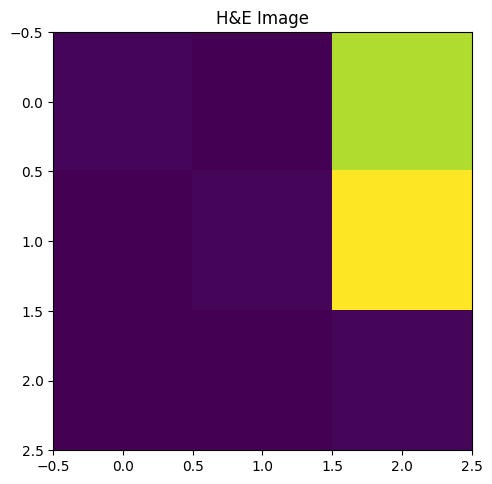

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# Plot the image
plt.figure(figsize=(5, 5))
plt.imshow(M_stored)
plt.title("H&E Image")
plt.tight_layout()
plt.show()

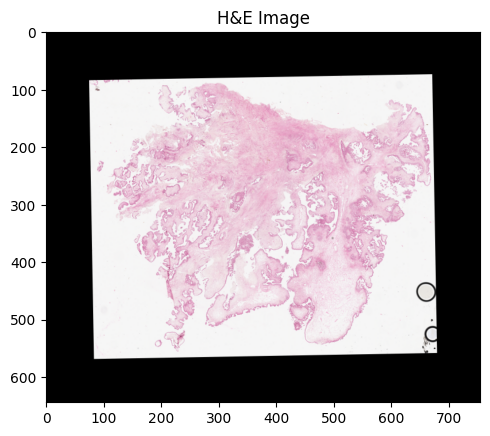

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# Plot the image
plt.figure(figsize=(5, 5))
plt.imshow(he_canvas2)
plt.title("H&E Image")
plt.tight_layout()
plt.show()

In [ ]:
annotation_gdf = None

In [30]:
sdata = _build_spatialdata(
        spectra_all            = spectra_all,
        peaks                  = peaks,
        maldi_pixel_um         = maldi_pixel_um,
        he_canvas              = he_canvas,
        maldi_offset_in_canvas = best_idx,
        reg_mpp                = loaded_mpp,
        crop_r                 = crop_r,
        crop_c                 = crop_c,
        img_upscaling          = img_upscaling,
    )

[0.84GB]   H&E upscaled 10x: 7470x6340  (142 MB)


/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


In [42]:
interactive = Interactive([sdata])
viewer = interactive.run()

2026-04-09 15:31:26.956 | WARNING  | napari_spatialdata._viewer:__init__:57 - Due to Shift-L being used as shortcut in napari, it is being deprecated and might not link a new layer to an existing SpatialData object in the viewer. Please use ⌘-L on MacOS or else Ctrl-L.


/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
2026-04-09 15:31:34.420 | DEBUG    | napari_spatialdata._view:_on_layer_update:569 - Updating layer.
2026-04-09 15:31:34.421 | DEBUG    | napari_spatialdata._view:_on_layer_update:569 - Updating layer.
2026-04-09 15:32:10.906 | DEBUG    | napari_spatialdata._view:_on_layer_update:569 - Updating layer.
2026-04-09 15:32:11.090 | DEBUG    | napari_spatialdata._view:_on_layer_update:569 - Updating layer.
2026-04-09 15:32:11.248 | DEBUG    | napari_spatialdata._view:_on_layer_update:569 - Updating layer.
